<a href="https://colab.research.google.com/github/singh00in/AIML_New/blob/master/ComputerVision/Project/HelmNet_Low_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **631 images**, equally divided into two categories:

- **With Helmet:** 311 images showing workers wearing helmets.
- **Without Helmet:** 320 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Please read the instructions carefully before starting the project.**

This is a commented Python Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_____' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_____' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations (wherever mentioned) derived from the analysis in the presentation and submit the same. Any mathematical or computational details which are a graded part of the project can be included in the Appendix section of the presentation.

**Note**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:

1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.

2. Switch to a different Google account and resume working on the project from there.

3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

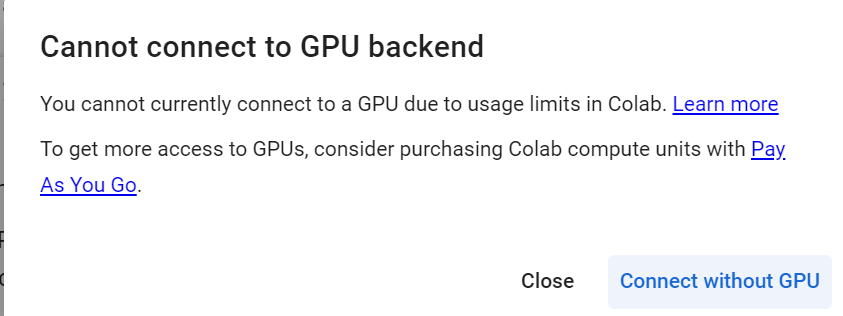

# **Installing and Importing the Necessary Libraries**

Original # install tensorflow[and-cuda]

In [ ]:
!pip install tensorflow==2.19.0 scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import math
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization
from tensorflow.keras.optimizers import Adam,SGD
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# **Data Overview**


##Loading the data

In [ ]:
# Uncomment and run the following code in case Google Colab is being used
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
images = np.load('/content/drive/My Drive/PG-AIML/ComputerVision/Project/images_proj.npy') #Complete the code to load the images

labels = pd.read_csv('/content/drive/My Drive/PG-AIML/ComputerVision/Project/Labels_proj.csv') #Complete the code to load the labels

In [ ]:
print(images.shape) #Complete the code to print the shape of the images
print(labels.shape) #Complete the code to print the shape of the labels

(631, 200, 200, 3)
(631, 1)


- With Helmet --> 311--> Label ==1
- Without Helmet-->320-->Label==0


In [ ]:
print(labels.value_counts())

Label
0        320
1        311
Name: count, dtype: int64


In [ ]:
print(labels.nunique)

<bound method DataFrame.nunique of      Label
0        1
1        1
2        1
3        1
4        1
..     ...
626      0
627      0
628      0
629      0
630      0

[631 rows x 1 columns]>


# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

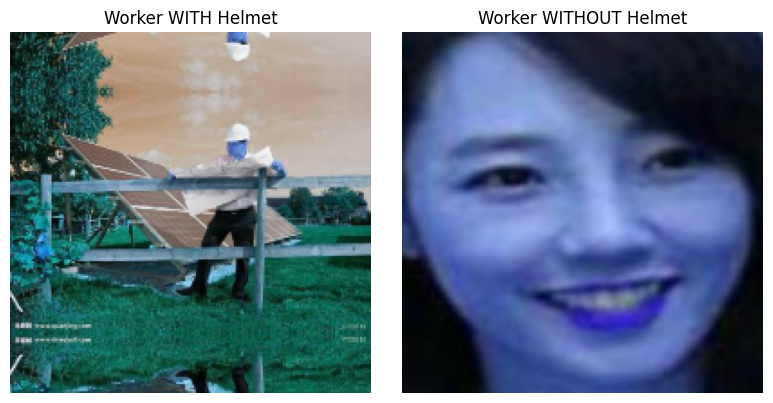

In [ ]:
helmet_indices = np.where(labels == 1)[0]
no_helmet_indices = np.where(labels == 0)[0]  #Complete the code to define an index (For example, 0,30,1,.etc)

# Select one image from each class
helmet_img = images[np.random.choice(helmet_indices)]
no_helmet_img = images[np.random.choice(no_helmet_indices)]

# Plot the images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Display "With Helmet" image
axes[0].imshow(helmet_img)
axes[0].set_title("Worker WITH Helmet")
axes[0].axis('off')

# Display "Without Helmet" image
axes[1].imshow(no_helmet_img)
axes[1].set_title("Worker WITHOUT Helmet")
axes[1].axis('off')

# Show the plots
plt.tight_layout()
plt.show()

## Checking for class imbalance


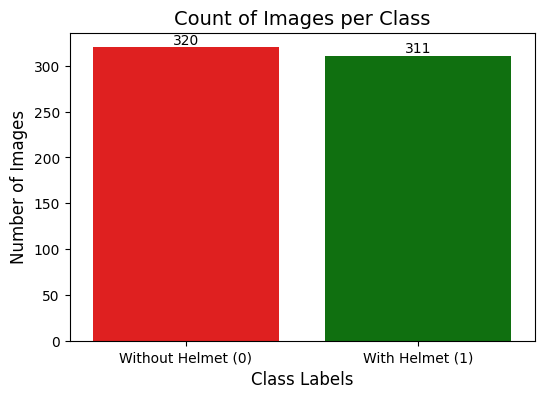

In [ ]:
# Create a count plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=labels.iloc[:, 0], palette=['red', 'green'])

# Add exact counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, )

# Add labels
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Count of Images per Class", fontsize=14)
plt.xticks(ticks=[0, 1], labels=["Without Helmet (0)", "With Helmet (1)"])  # Rename x-axis labels

# Show plot
plt.show()

# **Data Preprocessing**

## Converting images to grayscale

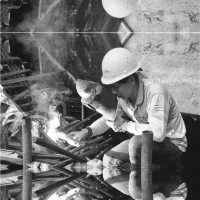

In [ ]:
images_gray = []
for i in range(len(images)):
    img_gray = cv2.cvtColor(images[i], cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    images_gray.append(img_gray)

# Display a sample grayscale image
n = 1  #Complete the code to define an index value
cv2_imshow(images_gray[n])

### Splitting the dataset

- As we have less images in our dataset, we will only use 10% of our data for testing, 10% of our data for validation and 80% of our data for training.
- We are using the train_test_split() function from scikit-learn. Here, we split the dataset into three parts, train,test and validation.



In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images),labels , test_size=0.2, random_state=42,stratify=labels) #Complete the code to define the test_size
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp) #Complete the code to define the test_size

In [ ]:
print(X_train.shape,y_train.shape) #Complete the code to print the shape of the train data
print(X_val.shape,y_val.shape) #Complete the code to print the shape of the validation data
print(X_test.shape,y_test.shape) #Complete the code to print the shape of the test data

(504, 200, 200, 3) (504, 1)
(63, 200, 200, 3) (63, 1)
(64, 200, 200, 3) (64, 1)


### Data Normalization

Since the **image pixel values range from 0-255**, our method of normalization here will be **scaling** - we shall **divide all the pixel values by 255 to standardize the images to have values between 0-1.**

In [ ]:
X_train_normalized = X_train.astype('float32')/255.0 #Complete the code to normalize the training images
X_val_normalized = X_val.astype('float32')/255.0  #Complete the code to normalize the validation images
X_test_normalized = X_test.astype('float32')/255.0   #Complete the code to normalize the test images

# **Model Building**

## Utility Functions

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [ ]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

**Yash Model 1_A: Simple Convolutional Neural Network (CNN)**
- Redusing the CNN layer to 32-->16-->8
- Increasing learning Rate .001

In [ ]:
path ='/content/drive/My Drive/PG-AIML/ComputerVision/Models/Trained_Model1A.keras'
model_1_A = tf.keras.models.load_model(path)


In [ ]:
# Initializing Model
model_1_A = Sequential()

# Convolutional layers
model_1_A.add(Conv2D(32, (3, 3), activation='relu', padding="same", input_shape=(200,200,3))) #Complete the code to define the shape of the input image
model_1_A.add(MaxPooling2D((4, 4), padding='same'))
model_1_A.add(Conv2D(32, (3, 3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function
model_1_A.add(MaxPooling2D((4,4), padding='same')) #Complete the code to define the shape of the pooling kernel
model_1_A.add(Conv2D(16, (3,3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function

# Flatten and Dense layers
model_1_A.add(Flatten())
model_1_A.add(Dense(4, activation='relu'))
model_1_A.add(Dense(1, activation='sigmoid'))  #Complete the code to define the number of neurons in the output layer and the activation function

# Compile with Adam Optimizer
opt = Adam(learning_rate=0.0001) #Complete the code to define the learning rate.
model_1_A.compile(optimizer=opt, loss='binary_crossentropy', metrics=["accuracy","Recall"]) #Complete the code to define the metric of choice from Precision,f1_score,Recall

# Summary
model_1_A.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │        10,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,593 (99.97 KB)

 Trainable params: 25,593 (99.97 KB)

 Non-trainable params: 0 (0.00 B)

**Model_1_A**
- Redusing the number of Epoch to 5
- Increasing the batch size

In [ ]:
history_1_A = model_1_A.fit(
            X_train_normalized, y_train,
            epochs=5, #Complete the code to define the number of epochs
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=128, #Complete the code to define the batch size
            verbose=2)

Epoch 1/5
4/4 - 15s - 4s/step - Recall: 1.0000 - accuracy: 0.4921 - loss: 0.6811 - val_Recall: 1.0000 - val_accuracy: 0.4921 - val_loss: 0.6771
Epoch 2/5
4/4 - 0s - 102ms/step - Recall: 1.0000 - accuracy: 0.4921 - loss: 0.6749 - val_Recall: 1.0000 - val_accuracy: 0.4921 - val_loss: 0.6705
Epoch 3/5
4/4 - 0s - 95ms/step - Recall: 1.0000 - accuracy: 0.4921 - loss: 0.6687 - val_Recall: 1.0000 - val_accuracy: 0.4921 - val_loss: 0.6645
Epoch 4/5
4/4 - 0s - 98ms/step - Recall: 1.0000 - accuracy: 0.4921 - loss: 0.6621 - val_Recall: 1.0000 - val_accuracy: 0.4921 - val_loss: 0.6582
Epoch 5/5
4/4 - 0s - 105ms/step - Recall: 1.0000 - accuracy: 0.4921 - loss: 0.6550 - val_Recall: 1.0000 - val_accuracy: 0.5397 - val_loss: 0.6504


In [ ]:
history_1_A1 = model_1_A.fit(
            X_train_normalized, y_train,
            epochs=20, #Complete the code to define the number of epochs
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=128, #Complete the code to define the batch size
            verbose=2)

Epoch 1/20
4/4 - 0s - 125ms/step - Recall: 1.0000 - accuracy: 0.5040 - loss: 0.6453 - val_Recall: 1.0000 - val_accuracy: 0.5714 - val_loss: 0.6393
Epoch 2/20
4/4 - 0s - 102ms/step - Recall: 1.0000 - accuracy: 0.5853 - loss: 0.6336 - val_Recall: 1.0000 - val_accuracy: 0.6508 - val_loss: 0.6280
Epoch 3/20
4/4 - 0s - 101ms/step - Recall: 1.0000 - accuracy: 0.7123 - loss: 0.6228 - val_Recall: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.6164
Epoch 4/20
4/4 - 0s - 98ms/step - Recall: 1.0000 - accuracy: 0.7520 - loss: 0.6104 - val_Recall: 1.0000 - val_accuracy: 0.6984 - val_loss: 0.6028
Epoch 5/20
4/4 - 0s - 101ms/step - Recall: 1.0000 - accuracy: 0.7817 - loss: 0.5959 - val_Recall: 1.0000 - val_accuracy: 0.7460 - val_loss: 0.5866
Epoch 6/20
4/4 - 0s - 99ms/step - Recall: 1.0000 - accuracy: 0.8333 - loss: 0.5787 - val_Recall: 1.0000 - val_accuracy: 0.8095 - val_loss: 0.5674
Epoch 7/20
4/4 - 0s - 99ms/step - Recall: 1.0000 - accuracy: 0.8790 - loss: 0.5589 - val_Recall: 1.0000 - val_accuracy: 

In [ ]:
plt.plot(history_1_A.history['Recall']) #Complete the code to plot the train metrics
plt.plot(history_1_A.history['val_Recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('Recall') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

NameError: name 'history_1_A' is not defined

In [ ]:
model_1_A_train_perf = model_performance_classification(model_1_A, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_A_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.494048  0.494048   0.750544  0.328937


In [ ]:
model_1_A_valid_perf = model_performance_classification(model_1_A, X_val_normalized,y_val)

print("Train performance metrics")
print(model_1_A_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.539683  0.539683   0.762169  0.422327


Saving my built Model

In [ ]:
import os

save_path = '/content/drive/My Drive/PG-AIML/ComputerVision/Models/'
# Create the directory if it does not exist
os.makedirs(save_path, exist_ok=True)

model_1_A.save(os.path.join(save_path, 'Trained_Model1A.keras'))

Model_B
Redusing the CNN layer to 32-->16-->8
Increasing learning Rate .001


In [ ]:
# Initializing Model
model_1_B = Sequential()

# Convolutional layers
model_1_B.add(Conv2D(32, (3, 3), activation='relu', padding="same", input_shape=(200,200,3))) #Complete the code to define the shape of the input image
model_1_B.add(MaxPooling2D((4, 4), padding='same'))
model_1_B.add(Conv2D(16, (3, 3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function
model_1_B.add(MaxPooling2D((4,4), padding='same')) #Complete the code to define the shape of the pooling kernel
model_1_B.add(Conv2D(8, (3,3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function

# Flatten and Dense layers
model_1_B.add(Flatten())
model_1_B.add(Dense(4, activation='relu'))
model_1_B.add(Dense(1, activation='sigmoid'))  #Complete the code to define the number of neurons in the output layer and the activation function

# Compile with Adam Optimizer
opt = Adam(learning_rate=0.0001) #Complete the code to define the learning rate.
model_1_B.compile(optimizer=opt, loss='binary_crossentropy', metrics=["accuracy","Recall"]) #Complete the code to define the metric of choice from Precision,f1_score,Recall

# Summary
model_1_B.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         5,412 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,097 (47.25 KB)

 Trainable params: 12,097 (47.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_1_B = model_1_B.fit(
            X_train_normalized, y_train,
            epochs=11, #Complete the code to define the number of epochs
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=128, #Complete the code to define the batch size
            verbose=2)

Epoch 1/11
4/4 - 8s - 2s/step - Recall: 0.2339 - accuracy: 0.5397 - loss: 0.6940 - val_Recall: 0.3226 - val_accuracy: 0.6032 - val_loss: 0.6936
Epoch 2/11
4/4 - 0s - 123ms/step - Recall: 0.3548 - accuracy: 0.5952 - loss: 0.6913 - val_Recall: 0.3871 - val_accuracy: 0.6349 - val_loss: 0.6913
Epoch 3/11
4/4 - 0s - 122ms/step - Recall: 0.4153 - accuracy: 0.6468 - loss: 0.6891 - val_Recall: 0.3871 - val_accuracy: 0.6508 - val_loss: 0.6891
Epoch 4/11
4/4 - 1s - 158ms/step - Recall: 0.3911 - accuracy: 0.6627 - loss: 0.6866 - val_Recall: 0.3226 - val_accuracy: 0.6508 - val_loss: 0.6869
Epoch 5/11
4/4 - 1s - 249ms/step - Recall: 0.3790 - accuracy: 0.6766 - loss: 0.6840 - val_Recall: 0.2903 - val_accuracy: 0.6349 - val_loss: 0.6845
Epoch 6/11
4/4 - 0s - 99ms/step - Recall: 0.3710 - accuracy: 0.6766 - loss: 0.6811 - val_Recall: 0.2903 - val_accuracy: 0.6349 - val_loss: 0.6817
Epoch 7/11
4/4 - 1s - 148ms/step - Recall: 0.3911 - accuracy: 0.6944 - loss: 0.6778 - val_Recall: 0.3548 - val_accuracy: 0

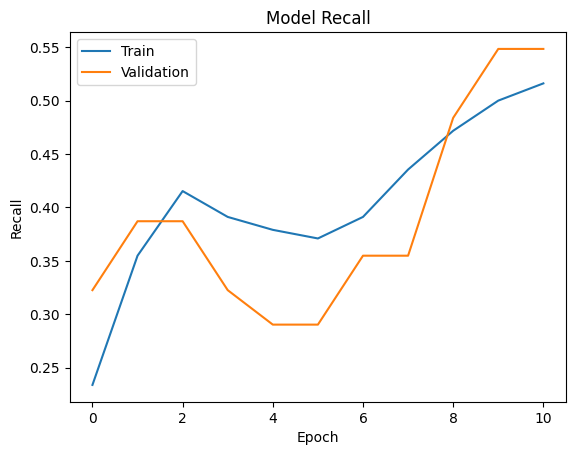

In [ ]:
plt.plot(history_1_B.history['Recall']) #Complete the code to plot the train metrics
plt.plot(history_1_B.history['val_Recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('Recall') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_1_B_train_perf = model_performance_classification(model_1_B, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_B_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.765873  0.765873   0.839742  0.751256


In [ ]:
model_1_B_valid_perf = model_performance_classification(model_1_B, X_val_normalized,y_val)

print("valid performance metrics")
print(model_1_B_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 631ms/step
valid performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.777778  0.777778   0.845411  0.765313


Model_1_C---------> **This is selected Model**

In [ ]:
# Initializing Model
model_1_C = Sequential()

# Convolutional layers
model_1_C.add(Conv2D(32, (3, 3), activation='relu', padding="same", input_shape=(200,200,3))) #Complete the code to define the shape of the input image
model_1_C.add(MaxPooling2D((4, 4), padding='same'))
model_1_C.add(Conv2D(32, (3, 3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function
model_1_C.add(MaxPooling2D((4,4), padding='same')) #Complete the code to define the shape of the pooling kernel
model_1_C.add(Conv2D(16, (3,3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function

# Flatten and Dense layers
model_1_C.add(Flatten())
model_1_C.add(Dense(4, activation='relu'))
model_1_C.add(Dense(1, activation='sigmoid'))  #Complete the code to define the number of neurons in the output layer and the activation function

# Compile with Adam Optimizer
opt = Adam(learning_rate=0.0001) #Complete the code to define the learning rate.
model_1_C.compile(optimizer=opt, loss='binary_crossentropy', metrics=["accuracy","Recall"]) #Complete the code to define the metric of choice from Precision,f1_score,Recall

# Summary
model_1_C.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │        10,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,593 (99.97 KB)

 Trainable params: 25,593 (99.97 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_1_C = model_1_C.fit(
            X_train_normalized, y_train,
            epochs=11, #Complete the code to define the number of epochs
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=128, #Complete the code to define the batch size
            verbose=2)

Epoch 1/11
4/4 - 7s - 2s/step - Recall: 0.0081 - accuracy: 0.5119 - loss: 0.7009 - val_Recall: 0.0645 - val_accuracy: 0.5397 - val_loss: 0.6905
Epoch 2/11
4/4 - 1s - 128ms/step - Recall: 0.2823 - accuracy: 0.6250 - loss: 0.6890 - val_Recall: 0.9032 - val_accuracy: 0.7778 - val_loss: 0.6818
Epoch 3/11
4/4 - 1s - 178ms/step - Recall: 0.9355 - accuracy: 0.6310 - loss: 0.6825 - val_Recall: 1.0000 - val_accuracy: 0.5714 - val_loss: 0.6786
Epoch 4/11
4/4 - 0s - 121ms/step - Recall: 0.9879 - accuracy: 0.5357 - loss: 0.6777 - val_Recall: 1.0000 - val_accuracy: 0.6032 - val_loss: 0.6723
Epoch 5/11
4/4 - 0s - 100ms/step - Recall: 0.9960 - accuracy: 0.6270 - loss: 0.6706 - val_Recall: 1.0000 - val_accuracy: 0.7302 - val_loss: 0.6647
Epoch 6/11
4/4 - 0s - 99ms/step - Recall: 0.9919 - accuracy: 0.7560 - loss: 0.6633 - val_Recall: 1.0000 - val_accuracy: 0.8571 - val_loss: 0.6568
Epoch 7/11
4/4 - 0s - 101ms/step - Recall: 0.9919 - accuracy: 0.8175 - loss: 0.6545 - val_Recall: 1.0000 - val_accuracy: 0

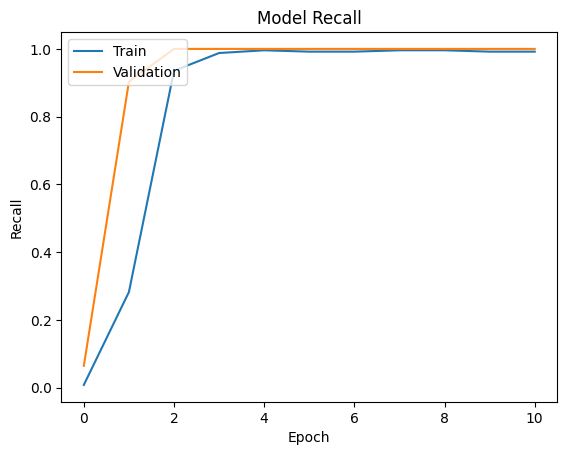

In [ ]:
plt.plot(history_1_C.history['Recall']) #Complete the code to plot the train metrics
plt.plot(history_1_C.history['val_Recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('Recall') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_1_C_train_perf = model_performance_classification(model_1_C, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_C_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.938492  0.938492   0.942935  0.938389


In [ ]:
model_1_C_valid_perf = model_performance_classification(model_1_C, X_val_normalized,y_val)

print("valid performance metrics")
print(model_1_C_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
valid performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.952381  0.952381   0.956583  0.952309


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


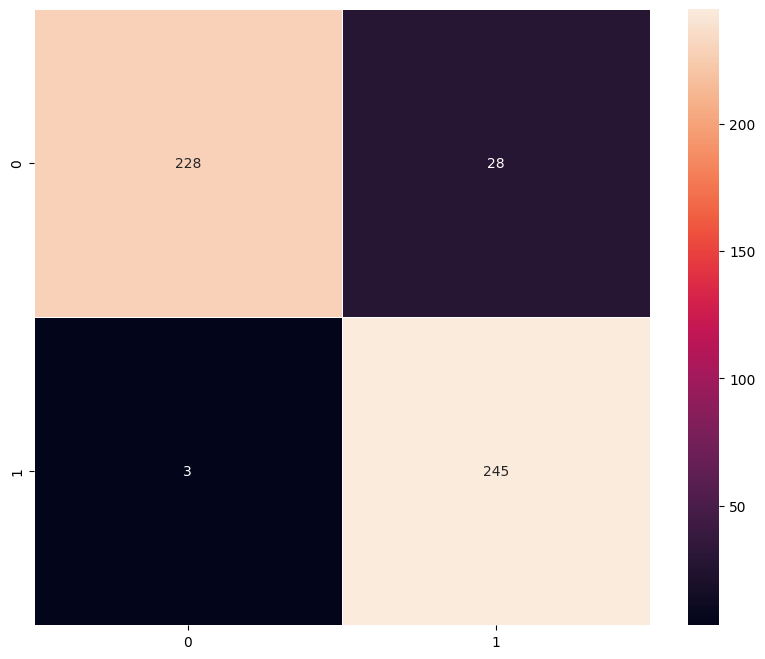

In [ ]:
plot_confusion_matrix(model_1_C,X_train_normalized,y_train)

plot_confusion_matrix(model_1_C,X_val_normalized,y_val)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


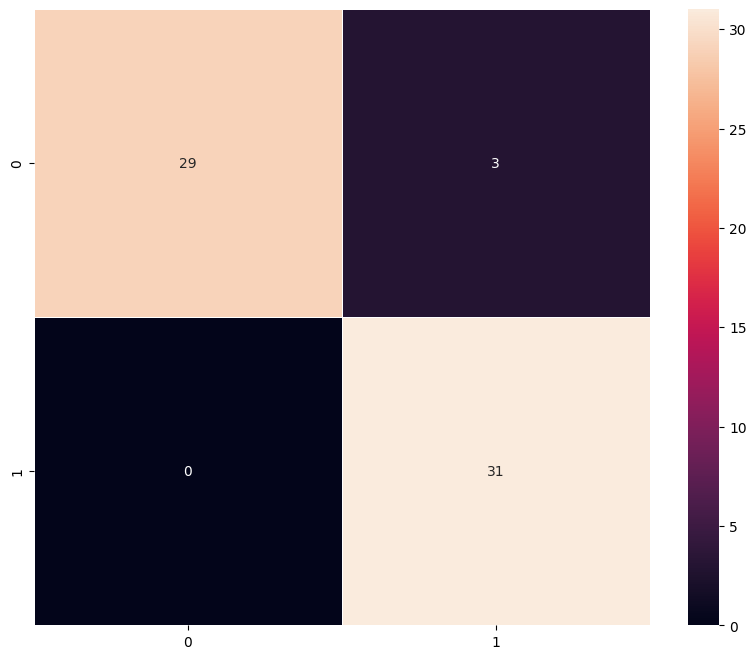

In [ ]:
plot_confusion_matrix(model_1_C,X_val_normalized,y_val)

Model1C

In [ ]:
# Initializing Model
model1C = Sequential()

# Convolutional layers
model1C.add(Conv2D(32, (3, 3), activation='relu', padding="same", input_shape=(200,200,3))) #Complete the code to define the shape of the input image
model1C.add(MaxPooling2D((4, 4), padding='same'))
model1C.add(Conv2D(32, (3, 3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function
model1C.add(MaxPooling2D((4,4), padding='same')) #Complete the code to define the shape of the pooling kernel
model1C.add(Conv2D(16, (3,3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function

# Flatten and Dense layers
model1C.add(Flatten())
model1C.add(Dense(4, activation='relu'))
model1C.add(Dense(1, activation='sigmoid'))  #Complete the code to define the number of neurons in the output layer and the activation function

# Compile with Adam Optimizer
opt = Adam(learning_rate=0.0001) #Complete the code to define the learning rate.
model1C.compile(optimizer=opt, loss='binary_crossentropy', metrics=["accuracy","Recall"]) #Complete the code to define the metric of choice from Precision,f1_score,Recall

# Summary
model1C.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 4)              │        10,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,593 (99.97 KB)

 Trainable params: 25,593 (99.97 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history1C = model1C.fit(
            X_train_normalized, y_train,
            epochs=11, #Complete the code to define the number of epochs
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=128, #Complete the code to define the batch size
            verbose=2)

Epoch 1/11
4/4 - 13s - 3s/step - Recall: 0.9597 - accuracy: 0.5595 - loss: 0.6787 - val_Recall: 1.0000 - val_accuracy: 0.6190 - val_loss: 0.6744
Epoch 2/11
4/4 - 0s - 104ms/step - Recall: 0.9879 - accuracy: 0.6012 - loss: 0.6690 - val_Recall: 1.0000 - val_accuracy: 0.6349 - val_loss: 0.6644
Epoch 3/11
4/4 - 0s - 102ms/step - Recall: 0.9960 - accuracy: 0.6310 - loss: 0.6572 - val_Recall: 1.0000 - val_accuracy: 0.6508 - val_loss: 0.6521
Epoch 4/11
4/4 - 0s - 104ms/step - Recall: 1.0000 - accuracy: 0.6071 - loss: 0.6425 - val_Recall: 1.0000 - val_accuracy: 0.5873 - val_loss: 0.6360
Epoch 5/11
4/4 - 0s - 102ms/step - Recall: 1.0000 - accuracy: 0.5635 - loss: 0.6244 - val_Recall: 1.0000 - val_accuracy: 0.6032 - val_loss: 0.6173
Epoch 6/11
4/4 - 0s - 98ms/step - Recall: 1.0000 - accuracy: 0.6389 - loss: 0.6038 - val_Recall: 1.0000 - val_accuracy: 0.7302 - val_loss: 0.5954
Epoch 7/11
4/4 - 0s - 98ms/step - Recall: 1.0000 - accuracy: 0.7619 - loss: 0.5795 - val_Recall: 1.0000 - val_accuracy: 0

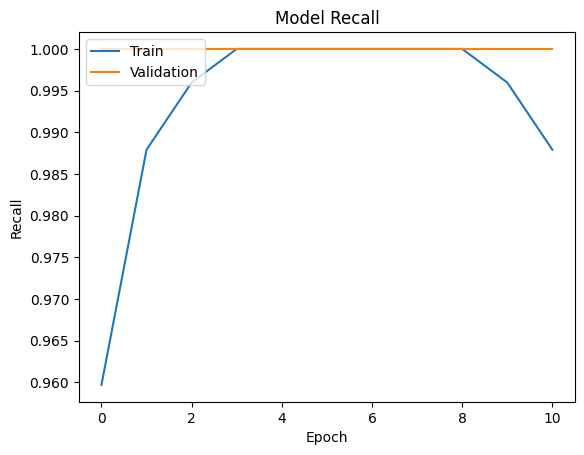

In [ ]:
plt.plot(history1C.history['Recall']) #Complete the code to plot the train metrics
plt.plot(history1C.history['val_Recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('Recall') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model1C_train_perf = model_performance_classification(model1C, X_train_normalized,y_train)
print("Train performance metrics")
print(model1C_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Train performance metrics
   Accuracy   Recall  Precision  F1 Score
0   0.94246  0.94246   0.946251  0.942382


In [ ]:
model1C_valid_perf = model_performance_classification(model1C, X_val_normalized,y_val)
print("valid performance metrics")
print(model_1_D_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
valid performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.888889  0.888889   0.909357  0.887702


Model_1_E

In [ ]:
# Initializing Model
model_1_E = Sequential()

# Convolutional layers
model_1_E.add(Conv2D(32, (3, 3), activation='relu', padding="same", input_shape=(200,200,3))) #Complete the code to define the shape of the input image
model_1_E.add(MaxPooling2D((4, 4), padding='same'))
model_1_E.add(Conv2D(32, (3, 3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function
model_1_E.add(MaxPooling2D((2,2), padding='same')) #Complete the code to define the shape of the pooling kernel
model_1_E.add(Conv2D(16, (3,3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function

# Flatten and Dense layers
model_1_E.add(Flatten())
model_1_E.add(Dense(4, activation='relu'))
model_1_E.add(Dense(1, activation='sigmoid'))  #Complete the code to define the number of neurons in the output layer and the activation function

# Compile with Adam Optimizer
opt = Adam(learning_rate=0.0001) #Complete the code to define the learning rate.
model_1_E.compile(optimizer=opt, loss='binary_crossentropy', metrics=["accuracy","Recall"]) #Complete the code to define the metric of choice from Precision,f1_score,Recall

# Summary
model_1_E.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 25, 25, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │        40,004 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,777 (213.97 KB)

 Trainable params: 54,777 (213.97 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_1_E = model_1_E.fit(
            X_train_normalized, y_train,
            epochs=15, #Complete the code to define the number of epochs
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=128, #Complete the code to define the batch size
            verbose=2)

Epoch 1/15
4/4 - 6s - 1s/step - Recall: 0.7782 - accuracy: 0.4742 - loss: 0.6907 - val_Recall: 1.0000 - val_accuracy: 0.4921 - val_loss: 0.6833
Epoch 2/15
4/4 - 0s - 100ms/step - Recall: 1.0000 - accuracy: 0.4921 - loss: 0.6768 - val_Recall: 1.0000 - val_accuracy: 0.4921 - val_loss: 0.6684
Epoch 3/15
4/4 - 0s - 107ms/step - Recall: 1.0000 - accuracy: 0.4921 - loss: 0.6621 - val_Recall: 1.0000 - val_accuracy: 0.4921 - val_loss: 0.6552
Epoch 4/15
4/4 - 0s - 100ms/step - Recall: 1.0000 - accuracy: 0.4921 - loss: 0.6491 - val_Recall: 1.0000 - val_accuracy: 0.4921 - val_loss: 0.6431
Epoch 5/15
4/4 - 0s - 96ms/step - Recall: 1.0000 - accuracy: 0.4921 - loss: 0.6340 - val_Recall: 1.0000 - val_accuracy: 0.4921 - val_loss: 0.6252
Epoch 6/15
4/4 - 0s - 101ms/step - Recall: 1.0000 - accuracy: 0.4940 - loss: 0.6136 - val_Recall: 1.0000 - val_accuracy: 0.5079 - val_loss: 0.6030
Epoch 7/15
4/4 - 0s - 93ms/step - Recall: 1.0000 - accuracy: 0.5833 - loss: 0.5908 - val_Recall: 1.0000 - val_accuracy: 0.

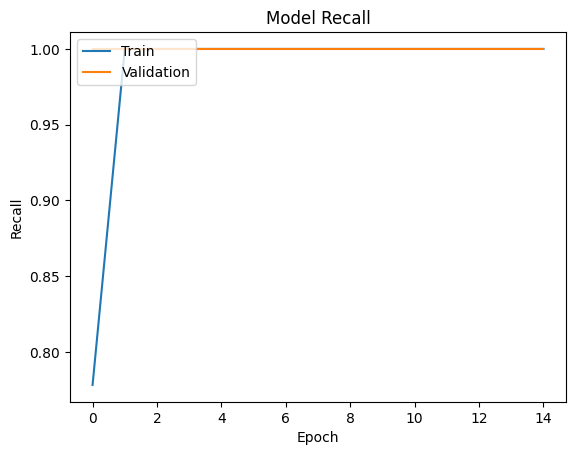

In [ ]:
plt.plot(history_1_E.history['Recall']) #Complete the code to plot the train metrics
plt.plot(history_1_E.history['val_Recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('Recall') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_1_E_train_perf = model_performance_classification(model_1_E, X_train_normalized,y_train)
print("Train performance metrics")
print(model_1_E_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.940476  0.940476     0.9469  0.940321


In [ ]:
model_1_E_valid_perf = model_performance_classification(model_1_E, X_val_normalized,y_val)
print("valid performance metrics")
print(model_1_E_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
valid performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.920635  0.920635   0.931658  0.920233


Model1-F

In [ ]:
# Initializing Model
model_1_F = Sequential()

# Convolutional layers
model_1_F.add(Conv2D(32, (3, 3), activation='relu', padding="same", input_shape=(200,200,3))) #Complete the code to define the shape of the input image
model_1_F.add(MaxPooling2D((4, 4), padding='same'))
model_1_F.add(Conv2D(32, (3, 3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function
model_1_F.add(MaxPooling2D((2,2), padding='same')) #Complete the code to define the shape of the pooling kernel
model_1_F.add(Conv2D(16, (3,3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function

# Flatten and Dense layers
model_1_F.add(Flatten())
model_1_F.add(Dense(4, activation='relu'))
model_1_F.add(Dense(1, activation='sigmoid'))  #Complete the code to define the number of neurons in the output layer and the activation function

# Compile with Adam Optimizer
opt = Adam(learning_rate=0.0001) #Complete the code to define the learning rate.
model_1_F.compile(optimizer=opt, loss='binary_crossentropy', metrics=["accuracy","Recall"]) #Complete the code to define the metric of choice from Precision,f1_score,Recall

# Summary
model_1_F.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │        40,004 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,777 (213.97 KB)

 Trainable params: 54,777 (213.97 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_1_F = model_1_F.fit(
            X_train_normalized, y_train,
            epochs=13, #Complete the code to define the number of epochs
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=128, #Complete the code to define the batch size
            verbose=2)

Epoch 1/13
4/4 - 12s - 3s/step - Recall: 0.9355 - accuracy: 0.5913 - loss: 0.6713 - val_Recall: 1.0000 - val_accuracy: 0.5873 - val_loss: 0.6451
Epoch 2/13
4/4 - 0s - 102ms/step - Recall: 1.0000 - accuracy: 0.5675 - loss: 0.6349 - val_Recall: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.6045
Epoch 3/13
4/4 - 0s - 100ms/step - Recall: 1.0000 - accuracy: 0.7341 - loss: 0.5906 - val_Recall: 1.0000 - val_accuracy: 0.8254 - val_loss: 0.5603
Epoch 4/13
4/4 - 0s - 101ms/step - Recall: 1.0000 - accuracy: 0.9008 - loss: 0.5439 - val_Recall: 1.0000 - val_accuracy: 0.9206 - val_loss: 0.5123
Epoch 5/13
4/4 - 0s - 107ms/step - Recall: 1.0000 - accuracy: 0.9147 - loss: 0.4951 - val_Recall: 1.0000 - val_accuracy: 0.9365 - val_loss: 0.4631
Epoch 6/13
4/4 - 0s - 109ms/step - Recall: 1.0000 - accuracy: 0.9325 - loss: 0.4451 - val_Recall: 1.0000 - val_accuracy: 0.9365 - val_loss: 0.4132
Epoch 7/13
4/4 - 0s - 101ms/step - Recall: 1.0000 - accuracy: 0.9603 - loss: 0.3954 - val_Recall: 1.0000 - val_accuracy:

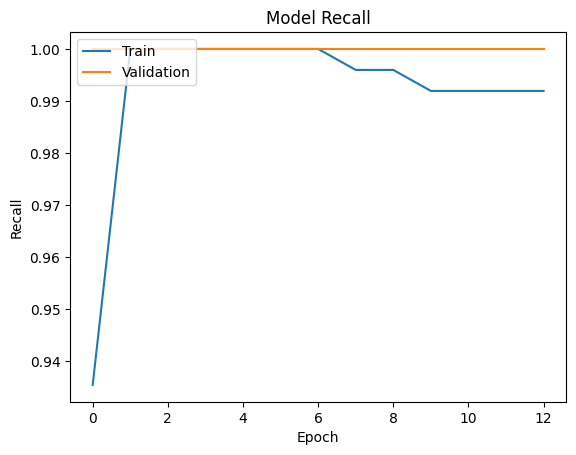

In [ ]:
plt.plot(history_1_F.history['Recall']) #Complete the code to plot the train metrics
plt.plot(history_1_F.history['val_Recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('Recall') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_1_F_train_perf = model_performance_classification(model_1_F, X_train_normalized,y_train)
print("Train performance metrics")
print(model_1_F_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.992063  0.992063   0.992063  0.992063


In [ ]:
model_1_F_valid_perf = model_performance_classification(model_1_F, X_val_normalized,y_val)
print("valid performance metrics")
print(model_1_F_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step
valid performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


Model 1_G

In [ ]:
# Initializing Model
model_1_G = Sequential()

# Convolutional layers
model_1_G.add(Conv2D(32, (3, 3), activation='relu', padding="same", input_shape=(200,200,3))) #Complete the code to define the shape of the input image
model_1_G.add(MaxPooling2D((4, 4), padding='same'))
model_1_G.add(Conv2D(32, (3, 3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function
model_1_G.add(MaxPooling2D((4,4), padding='same')) #Complete the code to define the shape of the pooling kernel
model_1_G.add(Conv2D(16, (3,3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function

# Flatten and Dense layers
model_1_G.add(Flatten())
model_1_G.add(Dense(4, activation='relu'))
model_1_G.add(Dense(1, activation='sigmoid'))  #Complete the code to define the number of neurons in the output layer and the activation function

# Compile with Adam Optimizer
opt = Adam(learning_rate=0.0001) #Complete the code to define the learning rate.
model_1_G.compile(optimizer=opt, loss='binary_crossentropy', metrics=["accuracy","Recall"]) #Complete the code to define the metric of choice from Precision,f1_score,Recall

# Summary
model_1_G.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │        10,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,593 (99.97 KB)

 Trainable params: 25,593 (99.97 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_1_G = model_1_G.fit(
            X_train_normalized, y_train,
            epochs=15, #Complete the code to define the number of epochs
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=128, #Complete the code to define the batch size
            verbose=2)

Epoch 1/15
4/4 - 6s - 1s/step - Recall: 1.0000 - accuracy: 0.4921 - loss: 0.6863 - val_Recall: 1.0000 - val_accuracy: 0.4921 - val_loss: 0.6831
Epoch 2/15
4/4 - 0s - 101ms/step - Recall: 1.0000 - accuracy: 0.4921 - loss: 0.6808 - val_Recall: 1.0000 - val_accuracy: 0.4921 - val_loss: 0.6783
Epoch 3/15
4/4 - 0s - 100ms/step - Recall: 1.0000 - accuracy: 0.4921 - loss: 0.6762 - val_Recall: 1.0000 - val_accuracy: 0.4921 - val_loss: 0.6737
Epoch 4/15
4/4 - 0s - 98ms/step - Recall: 1.0000 - accuracy: 0.4921 - loss: 0.6718 - val_Recall: 1.0000 - val_accuracy: 0.4921 - val_loss: 0.6692
Epoch 5/15
4/4 - 0s - 99ms/step - Recall: 1.0000 - accuracy: 0.4921 - loss: 0.6674 - val_Recall: 1.0000 - val_accuracy: 0.4921 - val_loss: 0.6645
Epoch 6/15
4/4 - 0s - 102ms/step - Recall: 1.0000 - accuracy: 0.4921 - loss: 0.6625 - val_Recall: 1.0000 - val_accuracy: 0.4921 - val_loss: 0.6593
Epoch 7/15
4/4 - 0s - 94ms/step - Recall: 1.0000 - accuracy: 0.4921 - loss: 0.6569 - val_Recall: 1.0000 - val_accuracy: 0.4

In [ ]:
model_1_G_train_perf = model_performance_classification(model_1_G, X_train_normalized,y_train)
print("Train performance metrics")
print(model_1_G_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.694444  0.694444   0.811498  0.664921


In [ ]:
model_1_G_valid_perf = model_performance_classification(model_1_G, X_val_normalized,y_val)
print("valid performance metrics")
print(model_1_G_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step
valid performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.634921  0.634921   0.790417  0.581913


##Model 1: Simple Convolutional Neural Network (CNN)

Let's build a **CNN Model**.<br>

The model has 2 main parts:
1. **The Feature Extraction layers** which are comprised of convolutional and pooling layers.
2. **The Fully Connected classification layers for prediction.**<br><br>





In [ ]:
# Initializing Model
model_1 = Sequential()

# Convolutional layers
model_1.add(Conv2D(32, (3, 3), activation='relu', padding="same", input_shape=(200,200,3))) #Complete the code to define the shape of the input image
model_1.add(MaxPooling2D((2, 2), padding='same'))
model_1.add(Conv2D(32, (3, 3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function
model_1.add(MaxPooling2D((2,2), padding='same')) #Complete the code to define the shape of the pooling kernel
model_1.add(Conv2D(16, (3,3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function

# Flatten and Dense layers
model_1.add(Flatten())
model_1.add(Dense(4, activation='relu'))
model_1.add(Dense(1, activation='sigmoid'))  #Complete the code to define the number of neurons in the output layer and the activation function

# Compile with Adam Optimizer
opt = Adam(learning_rate=0.0001) #Complete the code to define the learning rate.
model_1.compile(optimizer=opt, loss='binary_crossentropy', metrics=["accuracy","Recall"]) #Complete the code to define the metric of choice from Precision,f1_score,Recall

# Summary
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 50, 50, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │       160,004 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,777 (682.72 KB)

 Trainable params: 174,777 (682.72 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_1 = model_1.fit(
            X_train_normalized, y_train,
            epochs=20, #Complete the code to define the number of epochs
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=64, #Complete the code to define the batch size
            verbose=2
)

Epoch 1/20
8/8 - 15s - 2s/step - Recall: 0.5202 - accuracy: 0.5694 - loss: 0.6709 - val_Recall: 0.1613 - val_accuracy: 0.5873 - val_loss: 0.6224
Epoch 2/20
8/8 - 1s - 71ms/step - Recall: 0.8024 - accuracy: 0.6706 - loss: 0.6105 - val_Recall: 0.9677 - val_accuracy: 0.9206 - val_loss: 0.5359
Epoch 3/20
8/8 - 1s - 84ms/step - Recall: 0.8629 - accuracy: 0.8929 - loss: 0.5141 - val_Recall: 0.7742 - val_accuracy: 0.8730 - val_loss: 0.4495
Epoch 4/20
8/8 - 1s - 73ms/step - Recall: 0.9194 - accuracy: 0.8988 - loss: 0.4318 - val_Recall: 0.9355 - val_accuracy: 0.9524 - val_loss: 0.3494
Epoch 5/20
8/8 - 1s - 76ms/step - Recall: 0.9274 - accuracy: 0.9444 - loss: 0.3228 - val_Recall: 1.0000 - val_accuracy: 0.9841 - val_loss: 0.2386
Epoch 6/20
8/8 - 1s - 73ms/step - Recall: 0.9839 - accuracy: 0.9821 - loss: 0.2140 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.1402
Epoch 7/20
8/8 - 1s - 77ms/step - Recall: 0.9758 - accuracy: 0.9802 - loss: 0.1327 - val_Recall: 1.0000 - val_accuracy: 1.000

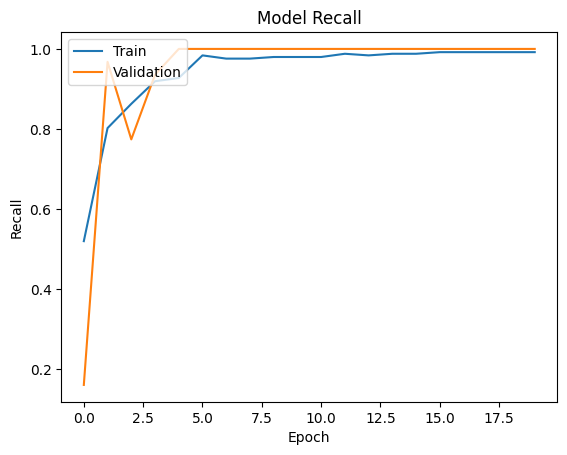

In [ ]:
plt.plot(history_1.history['Recall']) #Complete the code to plot the train metrics
plt.plot(history_1.history['val_Recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('Recall') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_1_train_perf = model_performance_classification(model_1, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.996032  0.996032   0.996032  0.996032


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


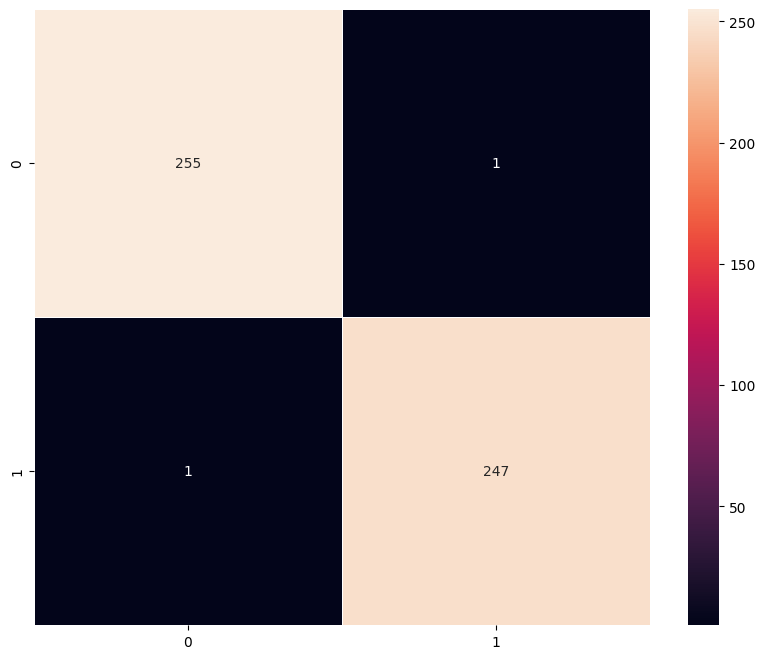

In [ ]:
plot_confusion_matrix(model_1,X_train_normalized,y_train)

In [ ]:
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_1_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


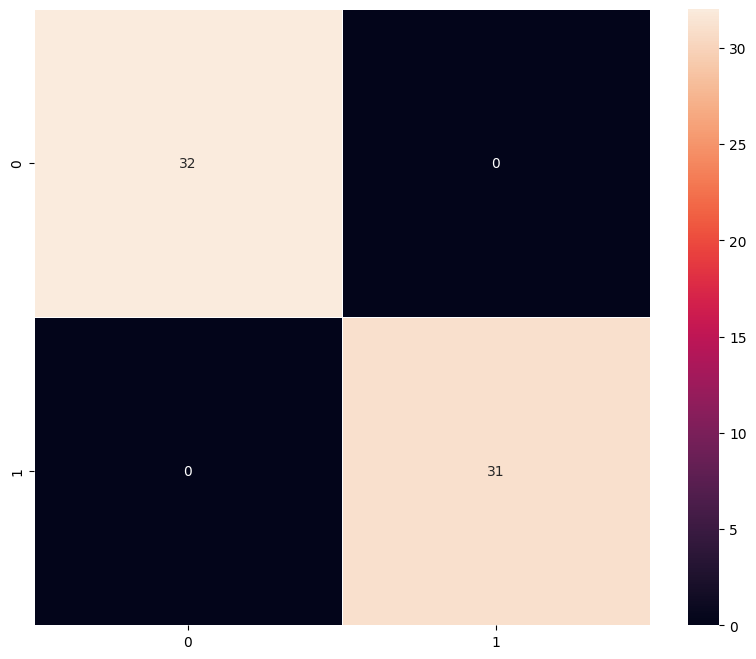

In [ ]:
plot_confusion_matrix(model_1,X_val_normalized,y_val)

### Vizualizing the predictions

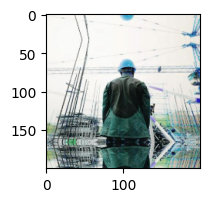

NameError: name 'model_1' is not defined

In [ ]:
# For index 2
plt.figure(figsize=(2,2))
plt.imshow(X_val[12])
plt.show()
prediction = model_1.predict(X_val_normalized[2].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[12]
print('True Label:', true_label)

# For index 33
plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()
prediction = model_1.predict(X_val_normalized[2].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[33]
print('True Label:', true_label)

## Model 2: (VGG-16 (Base))

- We will be loading a pre-built architecture - **VGG16**, which was trained on the ImageNet dataset and is the runner-up in the ImageNet competition in 2014.

- For training VGG16, we will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will add a Flatten and a single dense layer.


In [ ]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(200,200,3)) #Complete the code to define the shape of the image
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

In [ ]:
model2 = Sequential()
# Adding the convolutional part of the VGG16 model from above
model2.add(vgg_model)
# Flattening the output of the VGG16 model because it is from a convolutional layer
model2.add(Flatten())
# Adding a dense output layer
model2.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer.l

In [ ]:
opt=Adam(learning_rate=0.0001) #Complete the code to define the learning rate
# Compile model
model2.compile(optimizer=opt, loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
# Generating the summary of the model
model2.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
train_datagen = ImageDataGenerator()

In [ ]:
# Epochs
epochs = 6 #Complete the code to define the epochs
# Batch size
batch_size = 128 #Complete the code to define the batch size

history2 = model2.fit(train_datagen.flow(X_train_normalized,y_train,
                                      batch_size=batch_size,
                                      seed=42,
                                      shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 0.7782 - recall: 0.9973 - val_loss: 0.6587 - val_recall: 0.9677
Epoch 2/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - loss: 0.6606 - recall: 0.9833 - val_loss: 0.6176 - val_recall: 0.8710
Epoch 3/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 638ms/step - loss: 0.5699 - recall: 0.9429 - val_loss: 0.5350 - val_recall: 0.8387
Epoch 4/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - loss: 0.5165 - recall: 0.8214 - val_loss: 0.5154 - val_recall: 0.8065
Epoch 5/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 637ms/step - loss: 0.4677 - recall: 0.8543 - val_loss: 0.4612 - val_recall: 0.7742
Epoch 6/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - loss: 0.4355 - recall: 0.7500 - val_loss: 0.4419 - val_recall: 0.7742


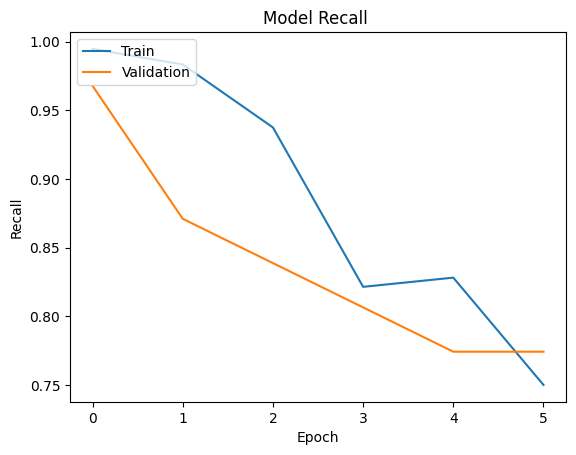

In [ ]:
plt.plot(history2.history['recall']) #Complete the code to plot the train metrics
plt.plot(history2.history['val_recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall ') #Complete the code to define the title for the plot
plt.ylabel('Recall') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step


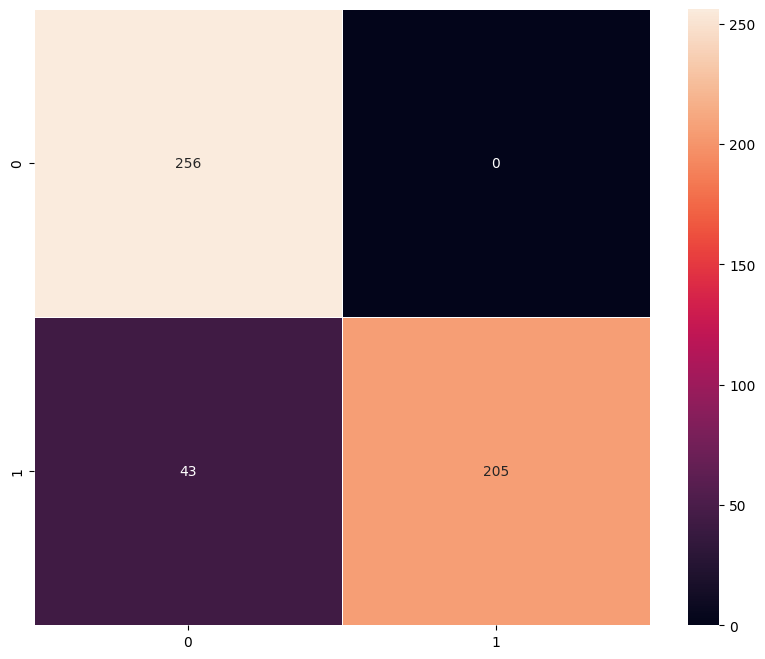

In [ ]:
plot_confusion_matrix(model2,X_train_normalized,y_train)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


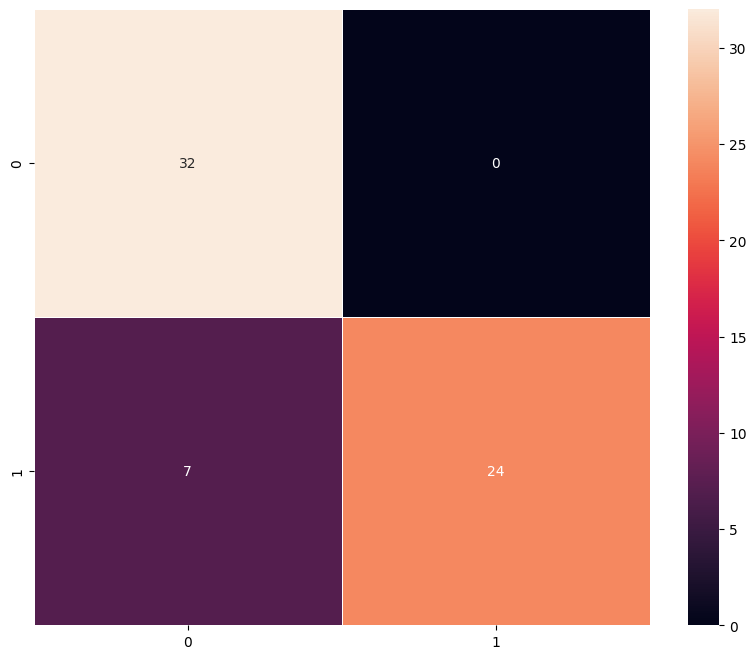

In [ ]:
plot_confusion_matrix(model2,X_val_normalized,y_val)

In [ ]:
model2_train_perf = model_performance_classification(model2,X_train_normalized,y_train)
print("Train performance metrics")
print(model2_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.914683  0.914683   0.926952  0.913938


In [ ]:
model2_valid_perf = model_performance_classification(model2, X_val_normalized,y_val)
print("Validation performance metrics")
print(model2_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.888889  0.888889   0.908832  0.887295


In [ ]:
import os

save_path = '/content/drive/My Drive/PG-AIML/ComputerVision/Models/'
# Create the directory if it does not exist
os.makedirs(save_path, exist_ok=True)

model2.save(os.path.join(save_path, 'Trained_Model2.keras'))

Model 2B------------->**This is selected Model**

In [ ]:
model2B = Sequential()
# Adding the convolutional part of the VGG16 model from above
model2B.add(vgg_model)
# Flattening the output of the VGG16 model because it is from a convolutional layer
model2B.add(Flatten())
# Adding a dense output layer
model2B.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer.


In [ ]:
 #Complete the code to define the metricsopt=Adam(learning_rate=0.0001) #Complete the code to define the learning rate
# Compile model
model2B.compile(optimizer=opt, loss=keras.losses.BinaryCrossentropy(), metrics=["recall"])

In [ ]:
model2B.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,769,989 (56.34 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 36,868 (144.02 KB)

In [ ]:
# Epochs
epochs = 6 #Complete the code to define the epochs
# Batch size
batch_size = 128 #Complete the code to define the batch size

history2B = model2B.fit(train_datagen.flow(X_train_normalized,y_train,
                                      batch_size=batch_size,
                                      seed=42,
                                      shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/6


NotImplementedError: numpy() is only available when eager execution is enabled.

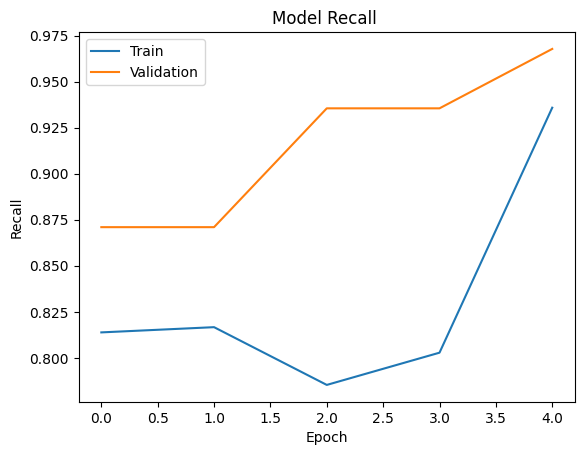

In [ ]:
plt.plot(history2B.history['recall']) #Complete the code to plot the train metrics
plt.plot(history2B.history['val_recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall ') #Complete the code to define the title for the plot
plt.ylabel('Recall') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_2_B_train_perf = model_performance_classification(model2B,X_train_normalized,y_train)
print("Train performance metrics")
print(model_2_B_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 229ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.982143  0.982143   0.982327  0.982138


In [ ]:
model_2_B_valid_perf = model_performance_classification(model2B, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_2_B_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.984127  0.984127   0.984608  0.984119


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step


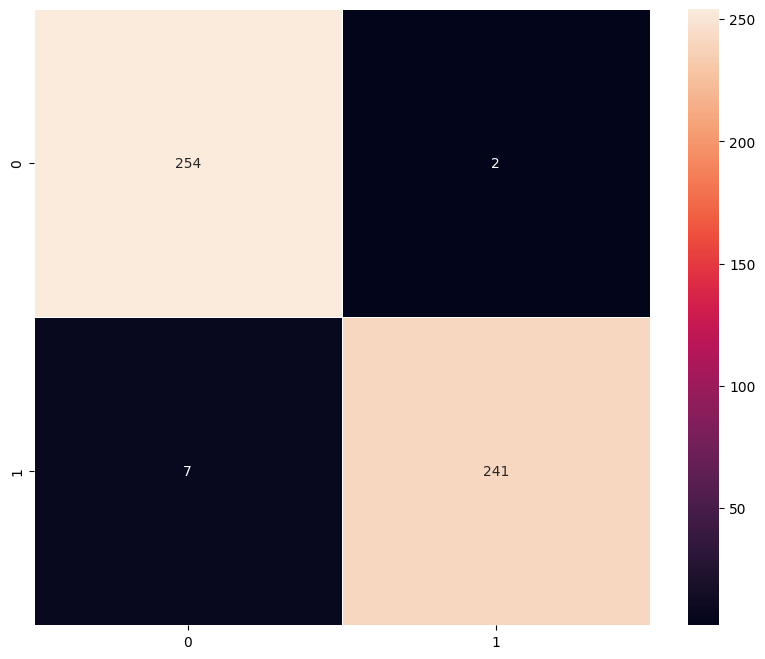

In [ ]:
plot_confusion_matrix(model_2_B,X_train_normalized,y_train)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


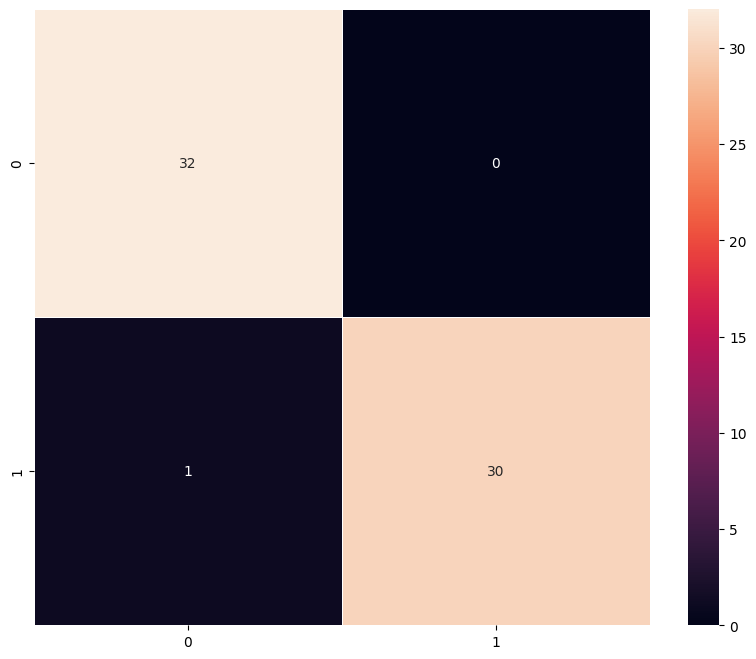

In [ ]:
plot_confusion_matrix(model_2_B,X_val_normalized,y_val)

In [ ]:
# Epochs
epochs = 20 #Complete the code to define the epochs
# Batch size
batch_size = 64 #Complete the code to define the batch size

history_2 = model_2.fit(train_datagen.flow(X_train_normalized,y_train,
                                      batch_size=batch_size,
                                      seed=42,
                                      shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 63s 7s/step - loss: 0.6866 - recall: 0.9447 - val_loss: 0.4924 - val_recall: 0.8065
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.4675 - recall: 0.8667 - val_loss: 0.4723 - val_recall: 0.8065
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 330ms/step - loss: 0.4322 - recall: 0.8566 - val_loss: 0.3442 - val_recall: 0.9677
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.3541 - recall: 0.8611 - val_loss: 0.3276 - val_recall: 0.9677
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 327ms/step - loss: 0.3059 - recall: 0.9897 - val_loss: 0.2443 - val_recall: 1.0000
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.2515 - recall: 1.0000 - val_loss: 0.2349 - val_recall: 1.0000
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 325ms/step - loss: 0.2209 - recall: 0.9931 - val_loss: 0.1807 - val_recall: 1.0000
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.1522 - recall: 1.0000 - val_loss: 0.1749 - val_recall: 1.0000
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━

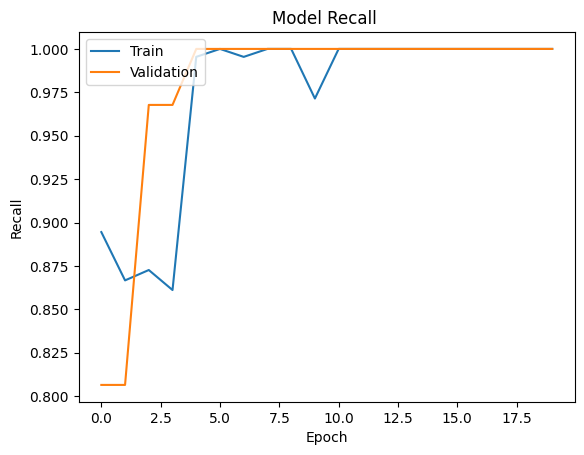

In [ ]:
plt.plot(history_2.history['recall']) #Complete the code to plot the train metrics
plt.plot(history_2.history['val_recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall ') #Complete the code to define the title for the plot
plt.ylabel('Recall') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_2_train_perf = model_performance_classification(model_2,X_train_normalized,y_train)
print("Train performance metrics")
print(model_2_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 786ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


In [ ]:
plot_confusion_matrix(model_2,X_train_normalized,y_train)

In [ ]:
model_2_valid_perf = model_performance_classification(model_2, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_2_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 571ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


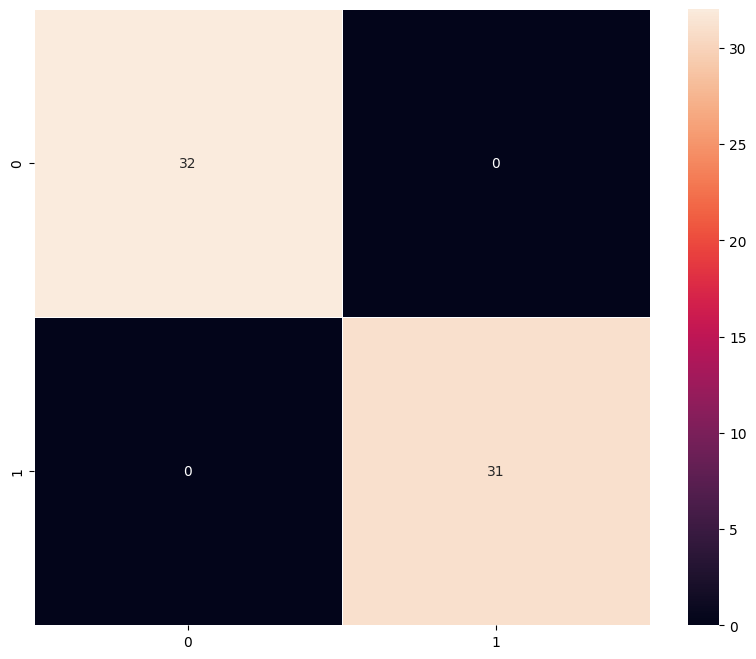

In [ ]:
plot_confusion_matrix(model_2,X_val_normalized,y_val)

In [ ]:
# Epochs
epochs = 10 #Complete the code to define the epochs
# Batch size
batch_size = 128 #Complete the code to define the batch size

history_21 = model_21.fit(train_datagen.flow(X_train_normalized,y_train,
                                      batch_size=batch_size,
                                      seed=42,
                                      shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - loss: 0.6115 - recall: 0.4105 - val_loss: 0.5028 - val_recall: 0.8710
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 169ms/step - loss: 0.5318 - recall: 0.7321 - val_loss: 0.4798 - val_recall: 0.9032
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 664ms/step - loss: 0.4796 - recall: 0.8819 - val_loss: 0.4171 - val_recall: 1.0000
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - loss: 0.4539 - recall: 0.9333 - val_loss: 0.3962 - val_recall: 1.0000
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 831ms/step - loss: 0.4068 - recall: 0.9408 - val_loss: 0.3388 - val_recall: 1.0000
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - loss: 0.3279 - recall: 0.9672 - val_loss: 0.3222 - val_recall: 1.0000
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 676ms/step - loss: 0.3110 - recall: 0.9757 - val_loss: 0.2790 - val_recall: 1.0000
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.2944 - recall: 0.9286 - val_loss: 0.2665 - val_recall: 1.0000
Epoch 9/10
3/3 ━━━━━━━━━━

In [ ]:
model_21_train_perf = model_performance_classification(model_21,X_train_normalized,y_train)

print("Train performance metrics")
print(model_2_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


In [ ]:
model_21_valid_perf = model_performance_classification(model_21,X_val_normalized,y_val)

print("Validation performance metrics")
print(model_21_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


### Visualizing the prediction:

In [ ]:
plt.figure(figsize=(2,2))
plt.imshow(X_val[_____]) #Complete the code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[_____].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[_____] #Complete the code to define the index
print('True Label:', true_label)

plt.figure(figsize=(2,2))
plt.imshow(X_val[_____]) #Complete the code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[_____].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[_____] #Complete the code to define the index
print('True Label:', true_label)

## Model 3: (VGG-16 (Base + FFNN))

- We will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will add a Flatten layer and a Feed Forward Neural Network.


In [ ]:
model_3 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3.add(Flatten())

#Adding the Feed Forward neural network
model_3.add(Dense(256,activation='relu')) #Complete the code to define the number of neurons and the activation function
model_3.add(Dropout(rate=0.4)) #Complete the code to define the dropout rate
model_3.add(Dense(32,activation='relu')) #Complete the code to define the number of neurons and the activation function

# Adding a dense output layer
model_3.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the activation function

In [ ]:
opt = Adam(learning_rate=0.0001) #Complete the code to define the learning rate

In [ ]:
# Compile model
model_3.compile(optimizer=opt,loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
# Generating the summary of the model
model_3.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,793 (74.16 MB)

 Trainable params: 4,727,105 (18.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history_3 = model_3.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=128, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=10, #Complete the code to define the number of epochs
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.6843 - recall: 0.7305 - val_loss: 0.2908 - val_recall: 0.9032
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - loss: 0.2984 - recall: 0.8667 - val_loss: 0.1663 - val_recall: 1.0000
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 669ms/step - loss: 0.1552 - recall: 0.9909 - val_loss: 0.0384 - val_recall: 1.0000
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - loss: 0.0513 - recall: 1.0000 - val_loss: 0.0243 - val_recall: 1.0000
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 684ms/step - loss: 0.0301 - recall: 1.0000 - val_loss: 0.0111 - val_recall: 1.0000
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 330ms/step - loss: 0.0107 - recall: 1.0000 - val_loss: 0.0096 - val_recall: 1.0000
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 681ms/step - loss: 0.0117 - recall: 1.0000 - val_loss: 0.0057 - val_recall: 1.0000
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.0074 - recall: 1.0000 - val_loss: 0.0046 - val_recall: 1.0000
Epoch 9/10
3/3 ━━━━━━━━━━━━

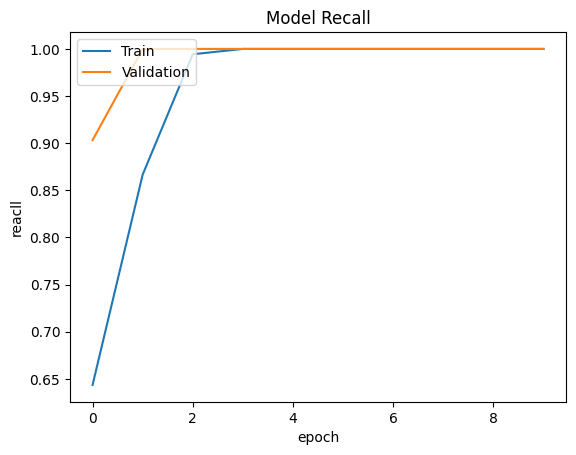

In [ ]:
plt.plot(history_3.history['recall']) #Complete the code to plot the train metrics
plt.plot(history_3.history['val_recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('reacll') #Complete the code to define the label for the y-axis
plt.xlabel('epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_3_train_perf = model_performance_classification(model_3, X_train_normalized,y_train)
print("Train performance metrics")
print(model_3_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step


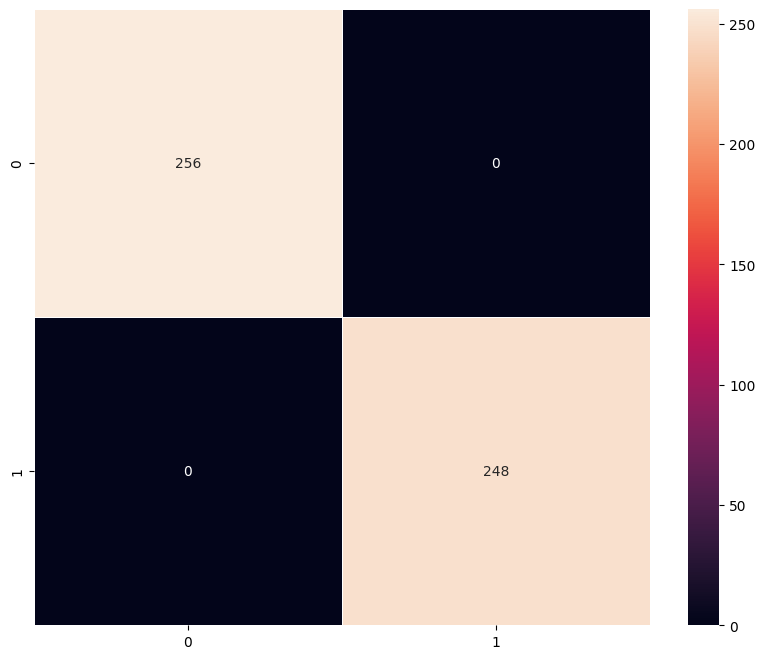

In [ ]:
plot_confusion_matrix(model_3,X_train_normalized,y_train)

In [ ]:
model_3_valid_perf = model_performance_classification(model_3, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_3_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


In [ ]:
plot_confusion_matrix(model_3,X_val_normalized,y_val)

Model_3_A

In [ ]:
model_3A = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3A.add(vgg_model)
# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3A.add(Flatten())
#Adding the Feed Forward neural network
model_3A.add(Dense(64,activation='relu')) #Complete the code to define the number of neurons and the activation function
model_3A.add(Dropout(rate=0.4)) #Complete the code to define the dropout rate
model_3A.add(Dense(32,activation='relu')) #Complete the code to define the number of neurons and the activation function
# Adding a dense output layer
model_3A.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the activation function

In [ ]:
opt = Adam(learning_rate=0.0001) #Complete the code to define the learning rate

In [ ]:
# Compile model
model_3A.compile(optimizer=opt,loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
# Generating the summary of the model
model_3A.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │     1,179,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,896,513 (60.64 MB)

 Trainable params: 1,181,825 (4.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history_3A = model_3A.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=128, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=5, #Complete the code to define the number of epochs
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.6898 - recall: 0.6807 - val_loss: 0.4428 - val_recall: 1.0000
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - loss: 0.4910 - recall: 0.9667 - val_loss: 0.3829 - val_recall: 1.0000
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 675ms/step - loss: 0.3980 - recall: 0.9519 - val_loss: 0.2236 - val_recall: 1.0000
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.2719 - recall: 1.0000 - val_loss: 0.1799 - val_recall: 1.0000
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 694ms/step - loss: 0.2211 - recall: 0.9907 - val_loss: 0.0917 - val_recall: 1.0000


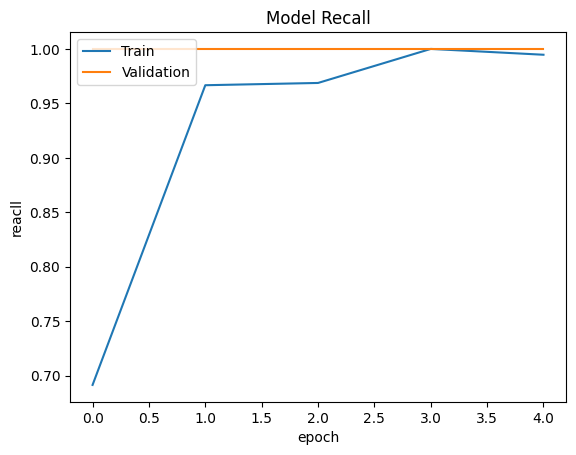

In [ ]:
plt.plot(history_3A.history['recall']) #Complete the code to plot the train metrics
plt.plot(history_3A.history['val_recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('reacll') #Complete the code to define the label for the y-axis
plt.xlabel('epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_3A_train_perf = model_performance_classification(model_3A, X_train_normalized,y_train)
print("Train performance metrics")
print(model_3A_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.998016  0.998016   0.998024  0.998016


In [ ]:
model_3A_valid_perf = model_performance_classification(model_3A, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_3A_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


Model_3B    --------> **This is NOT selected Model**

In [ ]:
model_3B = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3B.add(vgg_model)
# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3B.add(Flatten())
#Adding the Feed Forward neural network
model_3B.add(Dense(32,activation='relu')) #Complete the code to define the number of neurons and the activation function
model_3B.add(Dropout(rate=0.4)) #Complete the code to define the dropout rate
model_3B.add(Dense(16,activation='relu')) #Complete the code to define the number of neurons and the activation function
# Adding a dense output layer
model_3B.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the activation function

In [ ]:
opt = Adam(learning_rate=0.0001) #Complete the code to define the learning rate

In [ ]:
model_3B.compile(optimizer=opt,loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
model_3B.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │       589,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,305,089 (58.38 MB)

 Trainable params: 590,401 (2.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history_3B = model_3B.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=128, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=4, #Complete the code to define the number of epochs
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/4
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 0.7407 - recall: 0.1700 - val_loss: 0.5743 - val_recall: 0.7742
Epoch 2/4
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - loss: 0.5830 - recall: 0.6071 - val_loss: 0.5121 - val_recall: 0.8710
Epoch 3/4
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 677ms/step - loss: 0.5045 - recall: 0.6939 - val_loss: 0.3515 - val_recall: 0.9677
Epoch 4/4
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - loss: 0.3888 - recall: 0.8036 - val_loss: 0.3074 - val_recall: 0.9677


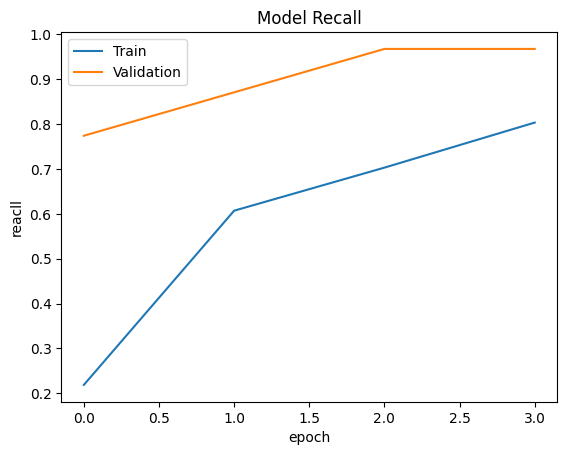

In [ ]:
plt.plot(history_3B.history['recall']) #Complete the code to plot the train metrics
plt.plot(history_3B.history['val_recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('reacll') #Complete the code to define the label for the y-axis
plt.xlabel('epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_3B_train_perf = model_performance_classification(model_3B, X_train_normalized,y_train)
print("Train performance metrics")
print(model_3B_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 202ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.988095  0.988095   0.988368  0.988091


In [ ]:
model_3B_valid_perf = model_performance_classification(model_3B, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_3B_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.984127  0.984127   0.984608  0.984119


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step


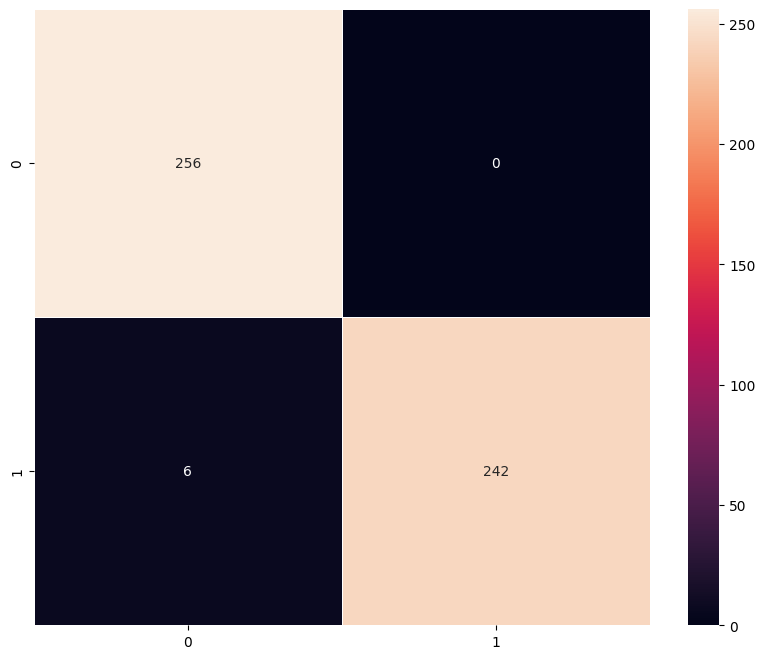

In [ ]:
plot_confusion_matrix(model_3B,X_train_normalized,y_train)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


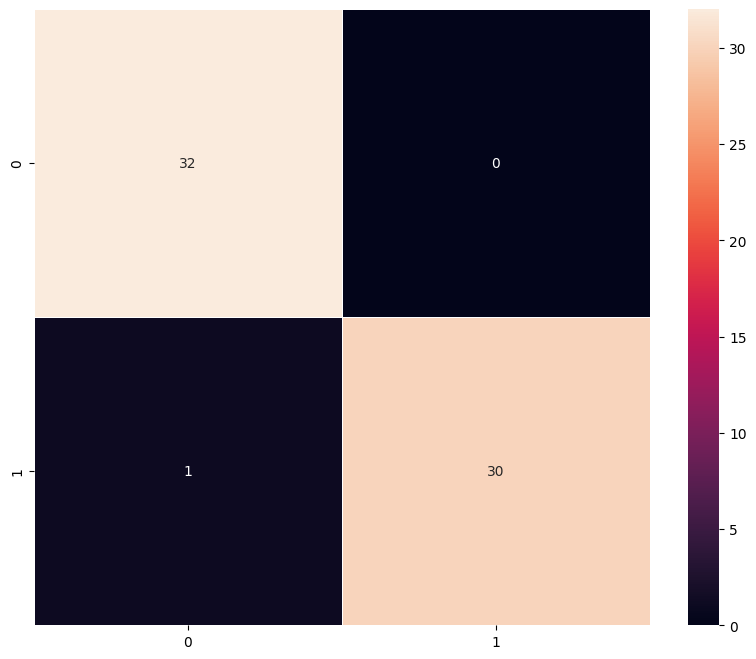

In [ ]:
plot_confusion_matrix(model_3B,X_val_normalized,y_val)

Model_3C

In [ ]:
model_3C = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3C.add(vgg_model)
# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3C.add(Flatten())
#Adding the Feed Forward neural network
model_3C.add(Dense(32,activation='relu')) #Complete the code to define the number of neurons and the activation function
model_3C.add(Dropout(rate=0.4)) #Complete the code to define the dropout rate
model_3C.add(Dense(16,activation='relu')) #Complete the code to define the number of neurons and the activation function
# Adding a dense output layer
model_3C.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the activation function

In [ ]:
opt = Adam(learning_rate=0.0001) #Complete the code to define the learning rate

In [ ]:
model_3C.compile(optimizer=opt,loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
model_3C.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │       589,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,305,089 (58.38 MB)

 Trainable params: 590,401 (2.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history_3C = model_3C.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=128, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=8, #Complete the code to define the number of epochs
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 0.6985 - recall: 0.4143 - val_loss: 0.4812 - val_recall: 0.9032
Epoch 2/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - loss: 0.4736 - recall: 0.8361 - val_loss: 0.4210 - val_recall: 0.9677
Epoch 3/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 668ms/step - loss: 0.4093 - recall: 0.8767 - val_loss: 0.2909 - val_recall: 1.0000
Epoch 4/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.3220 - recall: 0.8929 - val_loss: 0.2589 - val_recall: 1.0000
Epoch 5/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 669ms/step - loss: 0.2843 - recall: 0.9380 - val_loss: 0.1749 - val_recall: 1.0000
Epoch 6/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.1899 - recall: 0.9836 - val_loss: 0.1522 - val_recall: 1.0000
Epoch 7/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 680ms/step - loss: 0.1819 - recall: 0.9849 - val_loss: 0.1030 - val_recall: 1.0000
Epoch 8/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - loss: 0.1613 - recall: 0.9718 - val_loss: 0.0912 - val_recall: 1.0000


In [ ]:
plt.plot(history_3C.history['recall']) #Complete the code to plot the train metrics
plt.plot(history_3C.history['val_recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('reacll') #Complete the code to define the label for the y-axis
plt.xlabel('epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_3C_train_perf = model_performance_classification(model_3C, X_train_normalized,y_train)
print("Train performance metrics")
print(model_3C_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


In [ ]:
model_3C_valid_perf = model_performance_classification(model_3C, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_3C_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 795ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


In [ ]:
history_3D = model_3D.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=128, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=8, #Complete the code to define the number of epochs
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Model_3D

In [ ]:
model_3D = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3D.add(vgg_model)
# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3D.add(Flatten())
#Adding the Feed Forward neural network
model_3D.add(Dense(32,activation='relu')) #Complete the code to define the number of neurons and the activation function
model_3D.add(Dropout(rate=0.4)) #Complete the code to define the dropout rate
model_3D.add(Dense(16,activation='relu')) #Complete the code to define the number of neurons and the activation function
# Adding a dense output layer
model_3D.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the activation function

In [ ]:
opt = Adam(learning_rate=0.0001)

In [ ]:
model_3D.compile(optimizer=opt,loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
model_3D.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │       589,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,305,089 (58.38 MB)

 Trainable params: 590,401 (2.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history_3D = model_3D.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=128, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=5, #Complete the code to define the number of epochs
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - loss: 0.7882 - recall: 0.8412 - val_loss: 0.5663 - val_recall: 0.9032
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - loss: 0.5640 - recall: 0.6901 - val_loss: 0.5248 - val_recall: 0.9032
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 662ms/step - loss: 0.5012 - recall: 0.7472 - val_loss: 0.3587 - val_recall: 0.9677
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - loss: 0.3765 - recall: 0.8689 - val_loss: 0.3038 - val_recall: 1.0000
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 664ms/step - loss: 0.3151 - recall: 0.9010 - val_loss: 0.1927 - val_recall: 1.0000


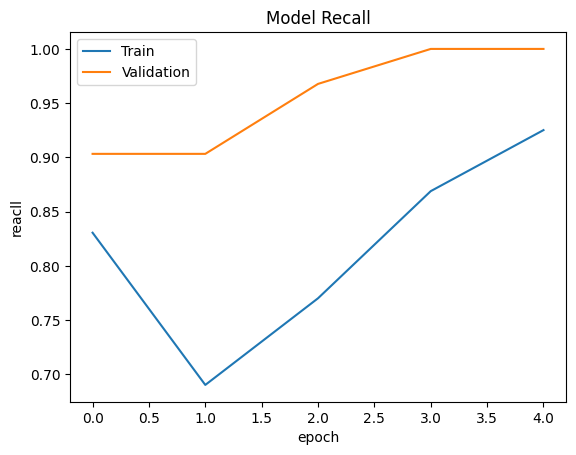

In [ ]:
plt.plot(history_3D.history['recall']) #Complete the code to plot the train metrics
plt.plot(history_3D.history['val_recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('reacll') #Complete the code to define the label for the y-axis
plt.xlabel('epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_3D_train_perf = model_performance_classification(model_3D, X_train_normalized,y_train)
print("Train performance metrics")
print(model_3D_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.998016  0.998016   0.998024  0.998016


In [ ]:
model_3D_valid_perf = model_performance_classification(model_3D, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_3D_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


Model 3E retrained 3B

In [ ]:
model_3E = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3E.add(vgg_model)
# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3E.add(Flatten())
#Adding the Feed Forward neural network
model_3E.add(Dense(32,activation='relu')) #Complete the code to define the number of neurons and the activation function
model_3E.add(Dropout(rate=0.4)) #Complete the code to define the dropout rate
model_3E.add(Dense(16,activation='relu')) #Complete the code to define the number of neurons and the activation function
# Adding a dense output layer
model_3E.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the activation function

In [ ]:
opt=Adam(learning_rate=0.0001)
model_3E.compile(optimizer=opt,loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
model_3E.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       589,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,305,089 (58.38 MB)

 Trainable params: 590,401 (2.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
batch_size=128
history_3E = model_3E.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=4, #Complete the code to define the number of epochs
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/4
3/3 ━━━━━━━━━━━━━━━━━━━━ 63s 12s/step - loss: 0.7156 - recall: 0.8533 - val_loss: 0.5580 - val_recall: 0.9032
Epoch 2/4
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 180ms/step - loss: 0.5497 - recall: 0.8750 - val_loss: 0.4941 - val_recall: 0.9355
Epoch 3/4
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 691ms/step - loss: 0.4688 - recall: 0.9361 - val_loss: 0.3408 - val_recall: 1.0000
Epoch 4/4
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - loss: 0.3680 - recall: 1.0000 - val_loss: 0.2965 - val_recall: 1.0000


In [ ]:
model_3E_train_perf = model_performance_classification(model_3E, X_train_normalized,y_train)
print("Train performance metrics")
print(model_3E_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 836ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


In [ ]:
model_3E_valid_perf = model_performance_classification(model_3E, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_3E_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 838ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


Model 3 F

In [ ]:
model_3F = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3F.add(vgg_model)
# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3F.add(Flatten())
#Adding the Feed Forward neural network
model_3F.add(Dense(16,activation='relu')) #Complete the code to define the number of neurons and the activation function
model_3F.add(Dropout(rate=0.4)) #Complete the code to define the dropout rate
model_3F.add(Dense(8,activation='relu')) #Complete the code to define the number of neurons and the activation function
# Adding a dense output layer
model_3F.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the activation function

In [ ]:
opt=Adam(learning_rate=0.0001)
model_3F.compile(optimizer=opt,loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
batch_size=128
history_3F = model_3F.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=4, #Complete the code to define the number of epochs
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/4
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 0.7244 - recall: 0.1040 - val_loss: 0.6505 - val_recall: 0.2903
Epoch 2/4
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step - loss: 0.6638 - recall: 0.2787 - val_loss: 0.6261 - val_recall: 0.4516
Epoch 3/4
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 832ms/step - loss: 0.6116 - recall: 0.5102 - val_loss: 0.5232 - val_recall: 0.8710
Epoch 4/4
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - loss: 0.5439 - recall: 0.7887 - val_loss: 0.4878 - val_recall: 0.9355


In [ ]:
model_3F_train_perf = model_performance_classification(model_3F, X_train_normalized,y_train)
print("Train performance metrics")
print(model_3F_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.988095  0.988095   0.988215  0.988093


In [ ]:
model_3F_valid_perf = model_performance_classification(model_3F, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_3F_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 609ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.968254  0.968254   0.970121  0.968206


In [ ]:
model_3G = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3G.add(vgg_model)
# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3G.add(Flatten())
#Adding the Feed Forward neural network
model_3G.add(Dense(16,activation='relu')) #Complete the code to define the number of neurons and the activation function
model_3G.add(Dropout(rate=0.4)) #Complete the code to define the dropout rate
model_3G.add(Dense(8,activation='relu')) #Complete the code to define the number of neurons and the activation function
# Adding a dense output layer
model_3G.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the activation function

In [ ]:
opt=Adam(learning_rate=0.0001)
model_3G.compile(optimizer=opt,loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
batch_size=128
history_3G = model_3G.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=5, #Complete the code to define the number of epochs
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 0.6387 - recall: 0.7969 - val_loss: 0.5554 - val_recall: 0.9355
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - loss: 0.5488 - recall: 0.8169 - val_loss: 0.5143 - val_recall: 0.9677
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 666ms/step - loss: 0.4854 - recall: 0.9032 - val_loss: 0.3986 - val_recall: 1.0000
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - loss: 0.4073 - recall: 0.9836 - val_loss: 0.3668 - val_recall: 1.0000
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 687ms/step - loss: 0.3953 - recall: 0.9835 - val_loss: 0.2998 - val_recall: 1.0000


In [ ]:
model_3G_train_perf = model_performance_classification(model_3G, X_train_normalized,y_train)
print("Train performance metrics")
print(model_3G_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 287ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.978175  0.978175   0.979102  0.978172


In [ ]:
model_3G_valid_perf = model_performance_classification(model_3G, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_3G_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


3H

In [ ]:
model3B = Sequential()

# Adding the convolutional part of the VGG16 model from above
model3B.add(vgg_model)
# Flattening the output of the VGG16 model because it is from a convolutional layer
model3B.add(Flatten())
#Adding the Feed Forward neural network
model3B.add(Dense(16,activation='relu')) #Complete the code to define the number of neurons and the activation function
model3B.add(Dropout(rate=0.4)) #Complete the code to define the dropout rate
model3B.add(Dense(4,activation='relu')) #Complete the code to define the number of neurons and the activation function
# Adding a dense output layer
model3B.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the activation function

In [ ]:
opt=Adam(learning_rate=0.0001)
model3B.compile(optimizer=opt,loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
batch_size=128
history3B = model3B.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=6, #Complete the code to define the number of epochs
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.7163 - recall: 0.8489 - val_loss: 0.6742 - val_recall: 0.8065
Epoch 2/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - loss: 0.6629 - recall: 0.8500 - val_loss: 0.6507 - val_recall: 0.9355
Epoch 3/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 699ms/step - loss: 0.5932 - recall: 0.9263 - val_loss: 0.4961 - val_recall: 1.0000
Epoch 4/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - loss: 0.5515 - recall: 1.0000 - val_loss: 0.4752 - val_recall: 1.0000
Epoch 5/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 717ms/step - loss: 0.5094 - recall: 1.0000 - val_loss: 0.4332 - val_recall: 1.0000
Epoch 6/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - loss: 0.4082 - recall: 0.9859 - val_loss: 0.4267 - val_recall: 1.0000


In [ ]:
model3K_train_perf = model_performance_classification(model3B, X_train_normalized,y_train)
print("Train performance metrics")
print(model3K_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step
Train performance metrics
   Accuracy   Recall  Precision  F1 Score
0   0.96627  0.96627   0.968434   0.96625


In [ ]:
model3B_valid_perf = model_performance_classification(model3B, X_val_normalized,y_val)
print("Validation performance metrics")
print(model3B_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.952381  0.952381   0.956583  0.952309


Model3C My top model selected

In [ ]:
model3C = Sequential()

# Adding the convolutional part of the VGG16 model from above
model3C.add(vgg_model)
# Flattening the output of the VGG16 model because it is from a convolutional layer
model3C.add(Flatten())
#Adding the Feed Forward neural network
model3C.add(Dense(16,activation='relu')) #Complete the code to define the number of neurons and the activation function
model3C.add(Dropout(rate=0.2)) #Complete the code to define the dropout rate
model3C.add(Dense(4,activation='relu')) #Complete the code to define the number of neurons and the activation function
# Adding a dense output layer
model3C.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the activation function

In [ ]:
opt=Adam(learning_rate=0.0001)
model3C.compile(optimizer=opt,loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
model3C.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       294,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,009,689 (57.26 MB)

 Trainable params: 295,001 (1.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
batch_size=128
history3C = model3C.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=6, #Complete the code to define the number of epochs
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 0.6681 - recall: 0.8011 - val_loss: 0.5773 - val_recall: 1.0000
Epoch 2/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step - loss: 0.5934 - recall: 0.9643 - val_loss: 0.5463 - val_recall: 1.0000
Epoch 3/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 706ms/step - loss: 0.5394 - recall: 0.9951 - val_loss: 0.4623 - val_recall: 1.0000
Epoch 4/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - loss: 0.4464 - recall: 1.0000 - val_loss: 0.4389 - val_recall: 1.0000
Epoch 5/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 745ms/step - loss: 0.4621 - recall: 1.0000 - val_loss: 0.4003 - val_recall: 1.0000
Epoch 6/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - loss: 0.3864 - recall: 1.0000 - val_loss: 0.3928 - val_recall: 1.0000


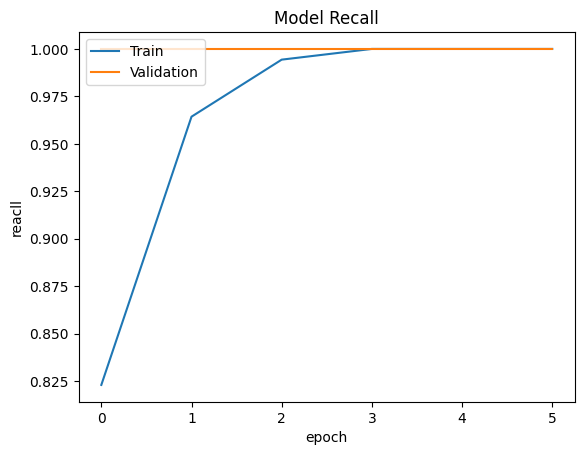

In [ ]:
plt.plot(history3C.history['recall']) #Complete the code to plot the train metrics
plt.plot(history3C.history['val_recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('reacll') #Complete the code to define the label for the y-axis
plt.xlabel('epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step


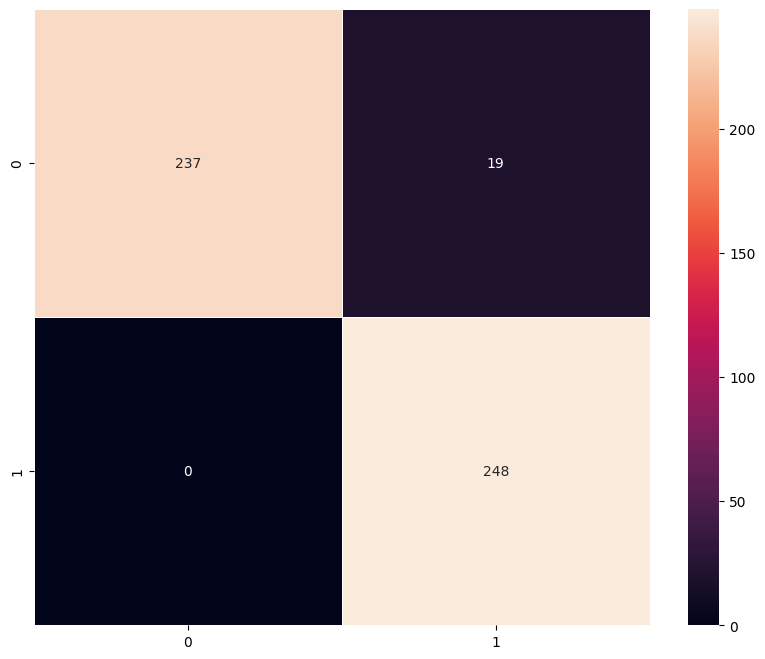

In [ ]:
plot_confusion_matrix(model3C,X_train_normalized,y_train)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


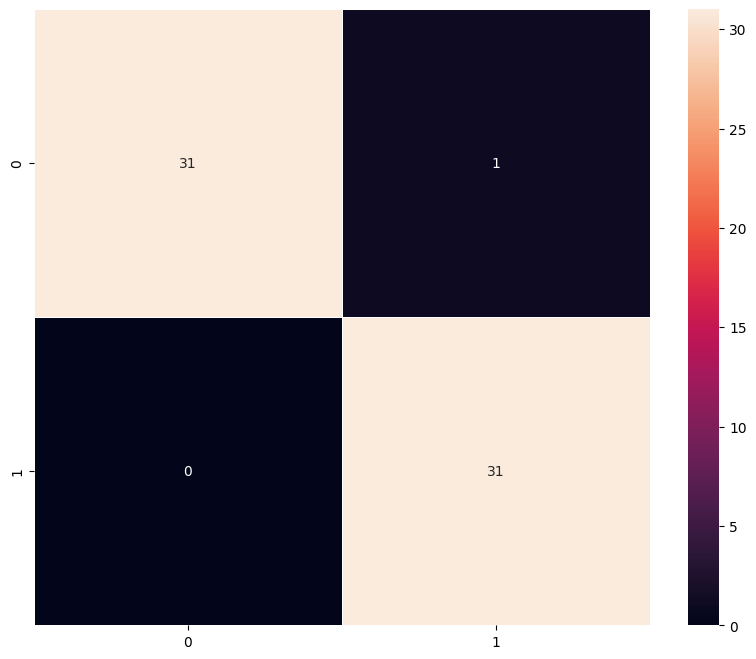

In [ ]:
plot_confusion_matrix(model3C,X_val_normalized,y_val)

In [ ]:
model3C_valid_perf = model_performance_classification(model3C, X_val_normalized,y_val)
print("Validation performance metrics")
print(model3C_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.984127  0.984127   0.984623  0.984127


In [ ]:
model3C_train_perf = model_performance_classification(model3C, X_train_normalized,y_train)
print("Train performance metrics")
print(model3C_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.962302  0.962302   0.964984  0.962271


In [ ]:
import os

save_path = '/content/drive/My Drive/PG-AIML/ComputerVision/Models/'
# Create the directory if it does not exist
os.makedirs(save_path, exist_ok=True)

model3C.save(os.path.join(save_path, 'Trained_Model3C.keras'))

In [ ]:
model3D = Sequential()

# Adding the convolutional part of the VGG16 model from above
model3D.add(vgg_model)
# Flattening the output of the VGG16 model because it is from a convolutional layer
model3D.add(Flatten())
#Adding the Feed Forward neural network
model3D.add(Dense(16,activation='relu')) #Complete the code to define the number of neurons and the activation function
model3D.add(Dropout(rate=0.2)) #Complete the code to define the dropout rate
model3D.add(Dense(4,activation='relu')) #Complete the code to define the number of neurons and the activation function
# Adding a dense output layer
model3D.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the activation function

In [ ]:
opt=Adam(learning_rate=0.0001)
model3D.compile(optimizer=opt,loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
batch_size=128
history3D = model3D.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=7, #Complete the code to define the number of epochs
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/7
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - loss: 0.6309 - recall: 0.4883 - val_loss: 0.4744 - val_recall: 1.0000
Epoch 2/7
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - loss: 0.5055 - recall: 0.8500 - val_loss: 0.4176 - val_recall: 1.0000
Epoch 3/7
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 673ms/step - loss: 0.4096 - recall: 0.9403 - val_loss: 0.2910 - val_recall: 1.0000
Epoch 4/7
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - loss: 0.3284 - recall: 0.9833 - val_loss: 0.2618 - val_recall: 1.0000
Epoch 5/7
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 663ms/step - loss: 0.2787 - recall: 0.9752 - val_loss: 0.1986 - val_recall: 1.0000
Epoch 6/7
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - loss: 0.2047 - recall: 0.9859 - val_loss: 0.1805 - val_recall: 1.0000
Epoch 7/7
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 678ms/step - loss: 0.2112 - recall: 0.9817 - val_loss: 0.1388 - val_recall: 1.0000


In [ ]:
model3D_train_perf = model_performance_classification(model3D, X_train_normalized,y_train)
print("Train performance metrics")
print(model3D_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


In [ ]:
model3D_valid_perf = model_performance_classification(model3D, X_val_normalized,y_val)
print("Validation performance metrics")
print(model3D_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 571ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


#### Visualizing the predictions

In [ ]:
plt.figure(figsize=(2,2))
plt.imshow(X_val[_____]) #Complete the code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[_____].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[_____] #Complete the code to define the index
print('True Label:', true_label)

plt.figure(figsize=(2,2))
plt.imshow(X_val[_____]) #Complete the code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[_____].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[_____] #Complete the code to define the index
print('True Label:', true_label)

## Model 4: (VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [ ]:
model_4 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_4.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_4.add(Flatten())

#Adding the Feed Forward neural network
model_4.add(Dense(32,activation='relu')) #Complete the code to define the number of neurons and the activation function
model_4.add(Dropout(rate=0.4)) #Complete the code to define the dropout rate
model_4.add(Dense(16,activation='relu')) #Complete the code to define the number of neurons and the activation function

# Adding a dense output layer
model_4.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the actiavtion function

In [ ]:
opt=Adam(learning_rate=0.0001)
# Compile model
model_4.compile(optimizer=opt,   loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
# Generating the summary of the model
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       589,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,305,089 (58.38 MB)

 Trainable params: 15,305,089 (58.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Applying data augmentation
train_datagen = ImageDataGenerator(
                              rotation_range=20, #Complete the code to define the range for rotation
                              fill_mode='nearest',width_shift_range=0.2,height_shift_range=0.2,shear_range=0.3,zoom_range=0.4
                              ) #Complete the code to define the parameters for the data augmentation

In [ ]:
batch_size=128
history_4 = model_4.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=5,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 144s 13s/step - loss: 0.6541 - recall: 0.4764 - val_loss: 0.2756 - val_recall: 1.0000
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 101s 176ms/step - loss: 0.3134 - recall: 0.9643 - val_loss: 0.0875 - val_recall: 1.0000
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 0.1382 - recall: 0.9613 - val_loss: 2.7760e-05 - val_recall: 1.0000
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - loss: 0.0409 - recall: 0.9821 - val_loss: 8.6650e-06 - val_recall: 1.0000
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 0.0471 - recall: 1.0000 - val_loss: 2.3352e-08 - val_recall: 1.0000


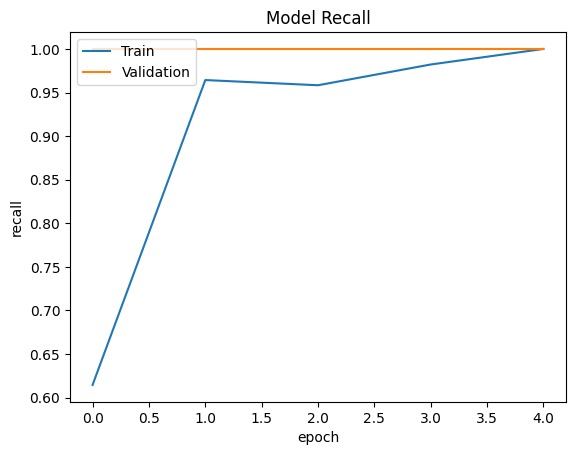

In [ ]:
plt.plot(history_4.history['recall']) #Complete the code to plot the train metrics
plt.plot(history_4.history['val_recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('recall') #Complete the code to define the label for the y-axis
plt.xlabel('epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_4_train_perf = model_performance_classification(model_4, X_train_normalized,y_train)
print("Train performance metrics")
print(model_4_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 742ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


In [ ]:
plot_confusion_matrix(model_4,X_train_normalized,y_train)

In [ ]:
model_4_valid_perf = model_performance_classification(model_4, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_4_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


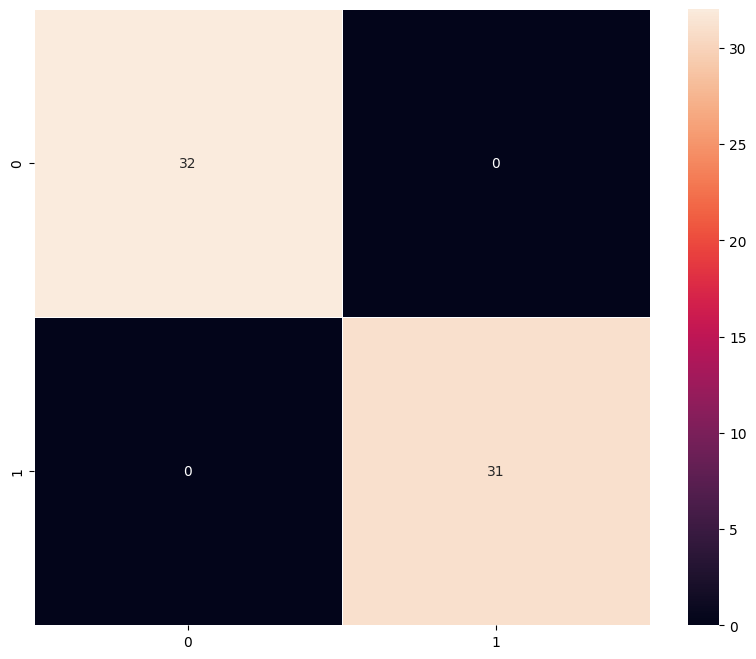

In [ ]:
plot_confusion_matrix(model_4,X_val_normalized,y_val)

#### Visualizing the predictions

Model 4A

In [ ]:
model_4A = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_4A.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_4A.add(Flatten())

#Adding the Feed Forward neural network
model_4A.add(Dense(16,activation='relu')) #Complete the code to define the number of neurons and the activation function
model_4A.add(Dropout(rate=0.4)) #Complete the code to define the dropout rate
model_4A.add(Dense(8,activation='relu')) #Complete the code to define the number of neurons and the activation function

# Adding a dense output layer
model_4A.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the actiavtion function

In [ ]:
opt=Adam(learning_rate=0.0001)
# Compile model
model_4A.compile(optimizer=opt,   loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
model_4A.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       294,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,009,761 (57.26 MB)

 Trainable params: 295,073 (1.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Applying data augmentation
train_datagen = ImageDataGenerator(
                              rotation_range=20, #Complete the code to define the range for rotation
                              fill_mode='nearest',width_shift_range=0.2,height_shift_range=0.2,shear_range=0.3,zoom_range=0.4
                              ) #Complete the code to define the parameters for the data augmentation

In [ ]:
batch_size=128
history_4A = model_4A.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=5,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 12s/step - loss: 0.6973 - recall: 0.7499 - val_loss: 0.6328 - val_recall: 0.9355
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 162ms/step - loss: 0.6372 - recall: 0.8036 - val_loss: 0.6135 - val_recall: 1.0000
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.6114 - recall: 0.7782 - val_loss: 0.5395 - val_recall: 1.0000
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 338ms/step - loss: 0.5732 - recall: 0.8571 - val_loss: 0.5173 - val_recall: 1.0000
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.5572 - recall: 0.8222 - val_loss: 0.4571 - val_recall: 1.0000


In [ ]:
plt.plot(history_4A.history['recall']) #Complete the code to plot the train metrics
plt.plot(history_4A.history['val_recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('recall') #Complete the code to define the label for the y-axis
plt.xlabel('epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_4A_train_perf = model_performance_classification(model_4A, X_train_normalized,y_train)
print("Train performance metrics")
print(model_4A_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 762ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.994048  0.994048   0.994119  0.994048


In [ ]:
model_4A_valid_perf = model_performance_classification(model_4A, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_4A_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


Model_4B

In [ ]:
model_4B = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_4B.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_4B.add(Flatten())

#Adding the Feed Forward neural network
model_4B.add(Dense(8,activation='relu')) #Complete the code to define the number of neurons and the activation function
model_4B.add(Dropout(rate=0.4)) #Complete the code to define the dropout rate
model_4B.add(Dense(4,activation='relu')) #Complete the code to define the number of neurons and the activation function

# Adding a dense output layer
model_4B.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the actiavtion function

In [ ]:
opt=Adam(learning_rate=0.0001)
# Compile model
model_4B.compile(optimizer=opt,   loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
model_4B.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │       147,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,862,193 (56.69 MB)

 Trainable params: 147,505 (576.19 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Applying data augmentation
train_datagen1 = ImageDataGenerator(
                              rotation_range=20, #Complete the code to define the range for rotation
                              fill_mode='nearest',width_shift_range=0.2,height_shift_range=0.2,shear_range=0.3,zoom_range=0.3
                              ) #Complete the code to define the parameters for the data augmentation

In [ ]:
batch_size=128
history_4B = model_4B.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=5,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - loss: 0.6960 - recall: 0.2168 - val_loss: 0.6429 - val_recall: 0.4516
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - loss: 0.6513 - recall: 0.4107 - val_loss: 0.6109 - val_recall: 0.5806
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 0.6119 - recall: 0.5988 - val_loss: 0.5099 - val_recall: 0.8710
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - loss: 0.5720 - recall: 0.7324 - val_loss: 0.4738 - val_recall: 0.9355
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - loss: 0.5236 - recall: 0.8349 - val_loss: 0.3845 - val_recall: 1.0000


In [ ]:
model_4B_train_perf = model_performance_classification(model_4B, X_train_normalized,y_train)
print("Train performance metrics")
print(model_4B_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.996032  0.996032   0.996032  0.996032


In [ ]:
model_4B_valid_perf = model_performance_classification(model_4B, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_4B_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


Model4E---> Selected

In [ ]:
model4E = Sequential()
# Adding the convolutional part of the VGG16 model from above
model4E.add(vgg_model)
# Flattening the output of the VGG16 model because it is from a convolutional layer
model4E.add(Flatten())
#Adding the Feed Forward neural network
model4E.add(Dense(16,activation='relu')) #Complete the code to define the number of neurons and the activation function
model4E.add(Dropout(rate=0.2)) #Complete the code to define the dropout rate
model4E.add(Dense(4,activation='relu')) #Complete the code to define the number of neurons and the activation function
# Adding a dense output layer
model4E.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the actiavtion function

In [ ]:
opt=Adam(learning_rate=0.0001)
# Compile model
model4E.compile(optimizer=opt,   loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
model4E.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       294,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,009,689 (57.26 MB)

 Trainable params: 295,001 (1.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
batch_size=128
history4E = model4E.fit(train_datagen1.flow(X_train_normalized,y_train,
                                       batch_size=batch_size, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=4,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/4
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.7325 - recall: 0.1290 - val_loss: 0.6774 - val_recall: 0.8710
Epoch 2/4
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - loss: 0.6699 - recall: 0.6786 - val_loss: 0.6747 - val_recall: 1.0000
Epoch 3/4
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - loss: 0.6836 - recall: 0.7281 - val_loss: 0.6268 - val_recall: 0.9677
Epoch 4/4
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - loss: 0.6219 - recall: 0.9000 - val_loss: 0.5921 - val_recall: 0.9355


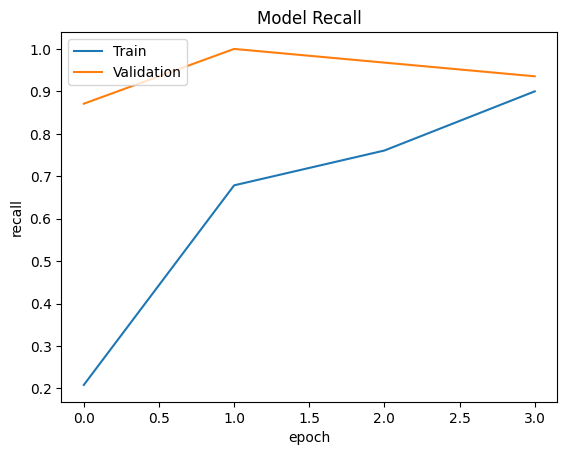

In [ ]:
plt.plot(history4E.history['recall']) #Complete the code to plot the train metrics
plt.plot(history4E.history['val_recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('recall') #Complete the code to define the label for the y-axis
plt.xlabel('epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model4E_train_perf = model_performance_classification(model4E, X_train_normalized,y_train)
print("Train performance metrics")
print(model4E_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.978175  0.978175   0.978774  0.978161


In [ ]:
model4E_valid_perf = model_performance_classification(model4E, X_val_normalized,y_val)
print("Validation performance metrics")
print(model4E_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.968254  0.968254   0.970121  0.968206


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step


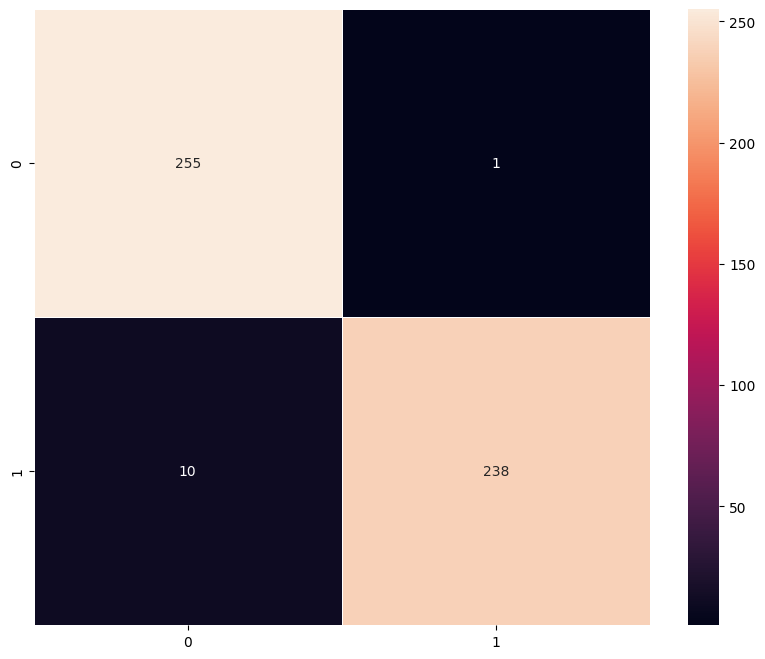

In [ ]:
plot_confusion_matrix(model4E,X_train_normalized,y_train)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


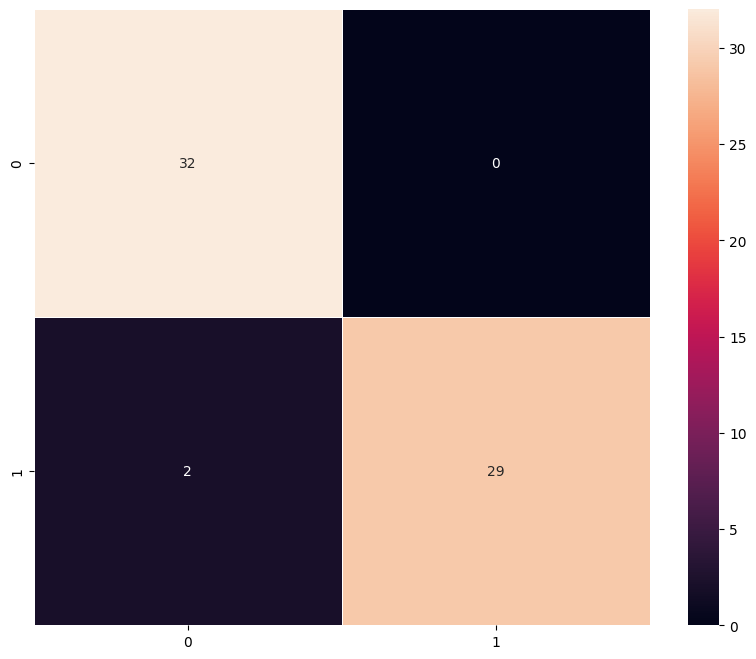

In [ ]:
plot_confusion_matrix(model4E,X_val_normalized,y_val)

In [ ]:
import os

save_path = '/content/drive/My Drive/PG-AIML/ComputerVision/Models/'
# Create the directory if it does not exist
os.makedirs(save_path, exist_ok=True)

model4E.save(os.path.join(save_path, 'Trained_Model4E.keras'))

Model4F is top model configuration --> need to put note

In [ ]:
model4F = Sequential()

# Adding the convolutional part of the VGG16 model from above
model4F.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model4F.add(Flatten())

#Adding the Feed Forward neural network
model4F.add(Dense(16,activation='relu')) #Complete the code to define the number of neurons and the activation function
model4F.add(Dropout(rate=0.2)) #Complete the code to define the dropout rate
model4F.add(Dense(4,activation='relu')) #Complete the code to define the number of neurons and the activation function

# Adding a dense output layer
model4F.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the actiavtion function

In [ ]:
opt=Adam(learning_rate=0.0001)
# Compile model
model4F.compile(optimizer=opt,   loss=keras.losses.BinaryCrossentropy(), metrics=["recall"]) #Complete the code to define the metrics

In [ ]:
batch_size=128
history4F = model4F.fit(train_datagen1.flow(X_train_normalized,y_train,
                                       batch_size=batch_size, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=6,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - loss: 0.7367 - recall: 0.9345 - val_loss: 0.6154 - val_recall: 0.7097
Epoch 2/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - loss: 0.6307 - recall: 0.7049 - val_loss: 0.5807 - val_recall: 0.6452
Epoch 3/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 0.5654 - recall: 0.7394 - val_loss: 0.4744 - val_recall: 0.9677
Epoch 4/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - loss: 0.4970 - recall: 0.8852 - val_loss: 0.4428 - val_recall: 1.0000
Epoch 5/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 0.4528 - recall: 0.9445 - val_loss: 0.3570 - val_recall: 1.0000
Epoch 6/6
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.3946 - recall: 0.9859 - val_loss: 0.3301 - val_recall: 1.0000


In [ ]:
model4F_train_perf = model_performance_classification(model4F, X_train_normalized,y_train)
print("Train performance metrics")
print(model4F_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 210ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


In [ ]:
model4F_valid_perf = model_performance_classification(model4F, X_val_normalized,y_val)
print("Validation performance metrics")
print(model4F_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


In [ ]:
plt.figure(figsize=(2,2))
plt.imshow(X_val[2]) #Complete the code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[2].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[_____] #Complete the code to define the index
print('True Label:', true_label)

plt.figure(figsize=(2,2))
plt.imshow(X_val[_____]) #Complete the code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[_____].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[_____] #Complete the code to define the index
print('True Label:', true_label)

NameError: name '_____' is not defined

<Figure size 200x200 with 0 Axes>

# **Model Performance Comparison and Final Model Selection**

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model1C_train_perf.T,
        model2_train_perf.T,
        model3C_train_perf.T,
        model4E_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [ ]:
models_valid_comp_df = pd.concat(
    [
        model1C_valid_perf.T,
        model2_valid_perf.T,
        model3C_valid_perf.T,
        model4E_valid_perf.T

    ],
    axis=1,
)
models_valid_comp_df.columns = [
 "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [ ]:
models_train_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.942460,0.914683,0.962302,0.978175
Recall,0.942460,0.914683,0.962302,0.978175
Precision,0.946251,0.926952,0.964984,0.978774
F1 Score,0.942382,0.913938,0.962271,0.978161


In [ ]:
models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.888889,0.888889,0.984127,0.968254
Recall,0.888889,0.888889,0.984127,0.968254
Precision,0.909357,0.908832,0.984623,0.970121
F1 Score,0.887702,0.887295,0.984127,0.968206


In [ ]:
models_train_comp_df - models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.053571,0.025794,-0.021825,0.009921
Recall,0.053571,0.025794,-0.021825,0.009921
Precision,0.036894,0.018120,-0.019639,0.008652
F1 Score,0.054680,0.026643,-0.021856,0.009956


## Test Performance

In [ ]:
model_test_perf = model_performance_classification(model3C, X_test_normalized,y_test) #Complete the code to pass the best model (Pass the variable corresponding to it. For example, model_1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


In [ ]:
model_test_perf

,Accuracy,Recall,Precision,F1 Score
0,1.0,1.0,1.0,1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


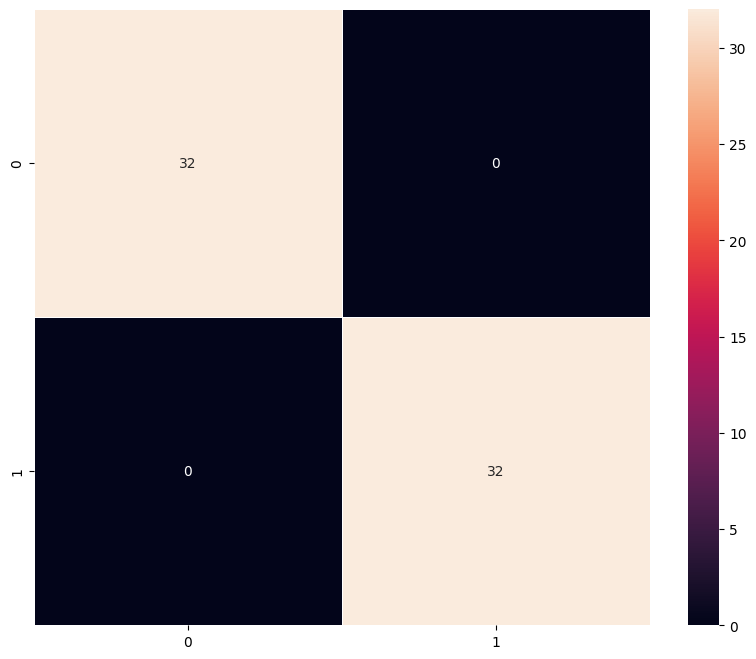

In [ ]:
plot_confusion_matrix(model3C, X_test_normalized,y_test) #Complete the code to pass the best model (Pass the variable corresponding to it. For example, model_1)

# **Actionable Insights & Recommendations**

-
-

<font size=5 color='blue'>Power Ahead!</font>
___